## part 3: analysis/ figures from random sampled TC data

In [1]:
!pip uninstall dea-tools -y


In [2]:
%pip install ultraplot -q


Note: you may need to restart the kernel to use updated packages.


In [52]:
import datacube
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import ultraplot as uplt
import cartopy.crs as ccrs
from matplotlib.dates import MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from datacube.utils import masking
from scipy.stats import linregress
import calendar
import warnings
import time
import odc.geo.xr
from odc.geo.geom import Geometry, CRS
from shapely.geometry import box

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, silhouette_score
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from math import sqrt
from itertools import combinations


from odc.algo._percentile import xr_quantile_bands

import sys

sys.path.insert(1, "../../../Tools")
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices
from dea_tools.spatial import add_geobox

warnings.filterwarnings("ignore")


### This version of the notebook reads in the .csv files from random sampled points across AU



In [4]:
def bias(x, y):
    return np.mean(x - y)


In [5]:
def add_arrow(head_pos, tail_pos, ax):
    style = "Simple, tail_width=0.01, head_width=1, head_length=2"
    kw = dict(arrowstyle=style, color="k", linewidth=0.2)
    arrow = patches.FancyArrowPatch(
        tail_pos, head_pos, connectionstyle="arc3,rad=.5", **kw
    )
    ax.add_patch(arrow)


In [6]:
csv_files = glob.glob("temp_outputs/*.csv")

output_dir = "figures"

colnames = [
    "class",
    "TCW",
    "TCB",
    "TCG",
    "TCW_DEA",
    "TCB_DEA",
    "TCG_DEA",
    "TCW_ls8",
    "TCB_ls8",
    "TCG_ls8",
]

dfs = []
for file in csv_files:
    classname = file.split("_")[3]
    df = pd.read_csv(file, usecols=colnames)
    df["classname"] = classname
    dfs.append(df)
    df["class"] = df["class"].astype(int)

cdf = pd.concat(dfs, ignore_index=True)


In [7]:
cdf


,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname
0,40,-0.259324,0.030067,0.359389,-0.146214,0.508730,-0.018039,-0.171598,0.503704,0.017596,cropland
1,40,-0.329175,0.027285,0.456748,-0.176440,0.641863,-0.024584,-0.223071,0.635684,0.014290,cropland
2,40,-0.371173,0.037492,0.453870,-0.231466,0.656902,-0.045289,-0.258875,0.655973,0.026277,cropland
3,40,-0.303116,0.049313,0.360724,-0.180570,0.533397,-0.017114,-0.208547,0.526216,0.037994,cropland
4,40,-0.296024,0.081780,0.342221,-0.207082,0.508471,-0.003859,-0.202317,0.503374,0.071998,cropland
...,...,...,...,...,...,...,...,...,...,...,...
3915,10,-0.042043,0.110668,0.141547,-0.081976,0.168345,0.070639,-0.003915,0.170136,0.101981,tree
3916,10,-0.117469,0.160574,0.251873,-0.139569,0.319139,0.099777,-0.052864,0.318423,0.149667,tree
3917,10,-0.133710,0.079012,0.203033,-0.096473,0.275270,0.047442,-0.085218,0.272751,0.073168,tree
3918,10,-0.139300,0.069037,0.196642,-0.101765,0.275373,0.030312,-0.088428,0.272337,0.062173,tree


In [8]:
# rename TC columns to make it clearer in output figures which is which

cdf = cdf.rename(
    columns={
        "class": "class_code",
        "TCW": "TCW_current_tcs",
        "TCG": "TCG_current_tcs",
        "TCB": "TCB_current_tcs",
        "TCW_DEA": "TCW_proposed_tcs_dea_internal",
        "TCG_DEA": "TCG_proposed_tcs_dea_internal",
        "TCB_DEA": "TCB_proposed_tcs_dea_internal",
        "TCW_ls8": "TCW_proposed_tcs_baig_2014",
        "TCG_ls8": "TCG_proposed_tcs_baig_2014",
        "TCB_ls8": "TCB_proposed_tcs_baig_2014",
        "classname": "class_name",
    }
)


In [9]:
cdf


,class_code,TCW_current_tcs,TCG_current_tcs,TCB_current_tcs,TCW_proposed_tcs_dea_internal,TCB_proposed_tcs_dea_internal,TCG_proposed_tcs_dea_internal,TCW_proposed_tcs_baig_2014,TCB_proposed_tcs_baig_2014,TCG_proposed_tcs_baig_2014,class_name
0,40,-0.259324,0.030067,0.359389,-0.146214,0.508730,-0.018039,-0.171598,0.503704,0.017596,cropland
1,40,-0.329175,0.027285,0.456748,-0.176440,0.641863,-0.024584,-0.223071,0.635684,0.014290,cropland
2,40,-0.371173,0.037492,0.453870,-0.231466,0.656902,-0.045289,-0.258875,0.655973,0.026277,cropland
3,40,-0.303116,0.049313,0.360724,-0.180570,0.533397,-0.017114,-0.208547,0.526216,0.037994,cropland
4,40,-0.296024,0.081780,0.342221,-0.207082,0.508471,-0.003859,-0.202317,0.503374,0.071998,cropland
...,...,...,...,...,...,...,...,...,...,...,...
3915,10,-0.042043,0.110668,0.141547,-0.081976,0.168345,0.070639,-0.003915,0.170136,0.101981,tree
3916,10,-0.117469,0.160574,0.251873,-0.139569,0.319139,0.099777,-0.052864,0.318423,0.149667,tree
3917,10,-0.133710,0.079012,0.203033,-0.096473,0.275270,0.047442,-0.085218,0.272751,0.073168,tree
3918,10,-0.139300,0.069037,0.196642,-0.101765,0.275373,0.030312,-0.088428,0.272337,0.062173,tree


In [10]:
for col in cdf.columns[1:4]:
    col_name = col.split("_")[0]
    cdf[f"diff_{col}_proposed_tcs_dea_internal"] = (
        cdf[col] - cdf[f"{col_name}_proposed_tcs_dea_internal"]
    )
    cdf[f"diff_{col}_proposed_tcs_baig_2014"] = (
        cdf[col] - cdf[f"{col_name}_proposed_tcs_baig_2014"]
    )


In [11]:
variable_pairs = {
    "proposed_tcs_baig_2014": [
        ("TCW_current_tcs", "TCW_proposed_tcs_baig_2014"),
        ("TCG_current_tcs", "TCG_proposed_tcs_baig_2014"),
        ("TCB_current_tcs", "TCB_proposed_tcs_baig_2014"),
    ],
    "proposed_tcs_dea_internal": [
        ("TCW_current_tcs", "TCW_proposed_tcs_dea_internal"),
        ("TCG_current_tcs", "TCG_proposed_tcs_dea_internal"),
        ("TCB_current_tcs", "TCB_proposed_tcs_dea_internal"),
    ],
}

worldcover_class_list = list(cdf["class_name"].unique())


In [12]:
worldcover_class_list


['cropland',
 'grassland',
 'wetland',
 'shrubland',
 'mangroves',
 'built-up',
 'bare',
 'tree']

In [13]:
cdf.head()


,class_code,TCW_current_tcs,TCG_current_tcs,TCB_current_tcs,TCW_proposed_tcs_dea_internal,TCB_proposed_tcs_dea_internal,TCG_proposed_tcs_dea_internal,TCW_proposed_tcs_baig_2014,TCB_proposed_tcs_baig_2014,TCG_proposed_tcs_baig_2014,class_name,diff_TCW_current_tcs_proposed_tcs_dea_internal,diff_TCW_current_tcs_proposed_tcs_baig_2014,diff_TCG_current_tcs_proposed_tcs_dea_internal,diff_TCG_current_tcs_proposed_tcs_baig_2014,diff_TCB_current_tcs_proposed_tcs_dea_internal,diff_TCB_current_tcs_proposed_tcs_baig_2014
0,40,-0.259324,0.030067,0.359389,-0.146214,0.508730,-0.018039,-0.171598,0.503704,0.017596,cropland,-0.113110,-0.087726,0.048106,0.012471,-0.149341,-0.144315
1,40,-0.329175,0.027285,0.456748,-0.176440,0.641863,-0.024584,-0.223071,0.635684,0.014290,cropland,-0.152735,-0.106104,0.051869,0.012995,-0.185115,-0.178936
2,40,-0.371173,0.037492,0.453870,-0.231466,0.656902,-0.045289,-0.258875,0.655973,0.026277,cropland,-0.139707,-0.112298,0.082781,0.011215,-0.203032,-0.202103
3,40,-0.303116,0.049313,0.360724,-0.180570,0.533397,-0.017114,-0.208547,0.526216,0.037994,cropland,-0.122546,-0.094569,0.066427,0.011319,-0.172673,-0.165492
4,40,-0.296024,0.081780,0.342221,-0.207082,0.508471,-0.003859,-0.202317,0.503374,0.071998,cropland,-0.088942,-0.093707,0.085639,0.009782,-0.166250,-0.161153


In [14]:
# Calculate RMSE, MAI and bias for each pixel/timestep
error_metrics_results = []

for i, group in variable_pairs.items():
    print(group)
    for j, (var1, var2) in enumerate(group):
        for cls, group in cdf.groupby("class_name"):
            rmse = root_mean_squared_error(group[var1], group[var2])
            mae = mean_absolute_error(group[var1], group[var2])
            vbias = bias(group[var1].values, group[var2].values)
            error_metrics_results.append(
                {"TC": var2, "class_name": cls, "RMSE": rmse, "MAE": mae, "bias": vbias}
            )

error_metrics_df = pd.DataFrame(error_metrics_results)


[('TCW_current_tcs', 'TCW_proposed_tcs_baig_2014'), ('TCG_current_tcs', 'TCG_proposed_tcs_baig_2014'), ('TCB_current_tcs', 'TCB_proposed_tcs_baig_2014')]
[('TCW_current_tcs', 'TCW_proposed_tcs_dea_internal'), ('TCG_current_tcs', 'TCG_proposed_tcs_dea_internal'), ('TCB_current_tcs', 'TCB_proposed_tcs_dea_internal')]


In [15]:
error_metrics_df.head()


,TC,class_name,RMSE,MAE,bias
0,TCW_proposed_tcs_baig_2014,bare,0.112897,0.108451,-0.108451
1,TCW_proposed_tcs_baig_2014,built-up,0.076923,0.075440,-0.075440
2,TCW_proposed_tcs_baig_2014,cropland,0.087374,0.085978,-0.085978
3,TCW_proposed_tcs_baig_2014,grassland,0.093286,0.090841,-0.090841
4,TCW_proposed_tcs_baig_2014,mangroves,0.049071,0.048152,-0.048152


In [16]:
for metric in ["RMSE", "MAE", "bias"]:
    f, axs = plt.subplots(3, 1, figsize=(7, 9), layout="constrained", sharex=True)
    # colors = iter([plt.cm.tab10(i) for i in range(6)])
    for i, (name, group) in enumerate(error_metrics_df.groupby("TC")):
        axs[i // 2].scatter(
            np.arange(group.shape[0]), group[metric], label=name, zorder=2
        )
    y_min = np.min([ax.get_ylim()[0] for ax in axs])
    y_max = np.max([ax.get_ylim()[1] for ax in axs])
    for ax in axs:
        ax.set_xticklabels([""] + list(group["class_name"]))
        ax.xaxis.minorticks_off()
        ax.legend()
        if metric == "bias":
            ax.set_ylim(-np.max((np.abs(y_min), y_max)), np.max((np.abs(y_min), y_max)))
            ax.axhline(0, c="k", lw=0.5, zorder=1)
        else:
            ax.set_ylim(0, y_max)
        ax.grid(visible=True)
    axs[0].set_title(f"{metric} between current and proposed TCs")
    f.savefig(
        f"{output_dir}/{metric}_between_current_and_proposed_tcs.png",
        dpi=100,
        bbox_inches="tight",
    )
    plt.close()


In [17]:
hist_test_dea = cdf[
    [
        "diff_TCW_current_tcs_proposed_tcs_dea_internal",
        "diff_TCG_current_tcs_proposed_tcs_dea_internal",
        "diff_TCB_current_tcs_proposed_tcs_dea_internal",
    ]
]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8, 4))
ax.format(
    suptitle="Histogram of differences between currently implemented and proposed coefficients (DEA developed) for TCW, TCG and TCB",
    xlabel="Difference",
    ylabel="Frequency",
)
res = ax.hist(
    hist_test_dea,
    bins=30,
    histtype="stepfilled",
    filled=True,
    alpha=0.6,
    edgecolor="k",
    cycle=("indigo4", "green4", "yellow4"),
    labels=list(["TCW", "TCG", "TCB"]),
    legend="ul",
)


fig.savefig(f"{output_dir}/histogram_tc_diff_dea.png", dpi=100, bbox_inches="tight")
plt.close()


In [18]:
hist_test_baig = cdf[
    [
        "diff_TCW_current_tcs_proposed_tcs_baig_2014",
        "diff_TCG_current_tcs_proposed_tcs_baig_2014",
        "diff_TCB_current_tcs_proposed_tcs_baig_2014",
    ]
]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8, 4))
ax.format(
    suptitle="Histogram of differences between the currently implemented and proposed coefficients (Baig et al) for TCW, TCG and TCB",
    xlabel="Difference",
    ylabel="Frequency",
)
res = ax.hist(
    hist_test_baig,
    bins=30,
    histtype="stepfilled",
    filled=True,
    alpha=0.6,
    edgecolor="k",
    cycle=("indigo4", "green4", "yellow4"),
    labels=list(["TCW", "TCG", "TCB"]),
    legend="ul",
)

fig.savefig(f"{output_dir}/histogram_tc_diff_baig.png", dpi=100, bbox_inches="tight")
plt.close()


In [19]:
sub_df = cdf[cdf["class_name"].isin(["mangroves", "tree"])]
sub_df.head()


,class_code,TCW_current_tcs,TCG_current_tcs,TCB_current_tcs,TCW_proposed_tcs_dea_internal,TCB_proposed_tcs_dea_internal,TCG_proposed_tcs_dea_internal,TCW_proposed_tcs_baig_2014,TCB_proposed_tcs_baig_2014,TCG_proposed_tcs_baig_2014,class_name,diff_TCW_current_tcs_proposed_tcs_dea_internal,diff_TCW_current_tcs_proposed_tcs_baig_2014,diff_TCG_current_tcs_proposed_tcs_dea_internal,diff_TCG_current_tcs_proposed_tcs_baig_2014,diff_TCB_current_tcs_proposed_tcs_dea_internal,diff_TCB_current_tcs_proposed_tcs_baig_2014
1997,95,-0.093516,0.057768,0.237256,-0.067571,0.297008,0.036694,-0.039717,0.295047,0.045636,mangroves,-0.025945,-0.053799,0.021074,0.012132,-0.059752,-0.057791
1998,95,-0.025812,0.156183,0.196006,-0.095522,0.218668,0.106859,0.024887,0.220293,0.142717,mangroves,0.069710,-0.050699,0.049324,0.013466,-0.022662,-0.024287
1999,95,-0.059427,0.148850,0.236550,-0.100395,0.277599,0.103571,-0.001029,0.277387,0.134741,mangroves,0.040968,-0.058398,0.045279,0.014109,-0.041049,-0.040837
2000,95,-0.056747,0.051871,0.216967,-0.047791,0.257218,0.038493,-0.009540,0.257339,0.039012,mangroves,-0.008956,-0.047207,0.013378,0.012859,-0.040251,-0.040372
2001,95,-0.024963,0.141619,0.249043,-0.081154,0.274504,0.104037,0.032943,0.275651,0.124962,mangroves,0.056191,-0.057906,0.037582,0.016657,-0.025461,-0.026608


In [20]:
# g = sns.PairGrid(sub_df, vars=['water', 'mangroves', 'tree'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_current_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()


In [21]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_DEA', 'TCG_DEA', 'TCB_DEA'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_dea_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()


In [22]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_ls8', 'TCG_ls8', 'TCB_ls8'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_baig_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()


In [23]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

combined_no_water_df = cdf[~cdf["class_name"].isin(["water"])]

classes = list(combined_no_water_df["class_name"].unique())
bandwidth = 0.5  # modified the 'smoothing' of the kde

darkgreen = "#9BC184"
midgreen = "#C2D6A4"
lightgreen = "#E7E5CB"
colors = [lightgreen, midgreen, darkgreen, midgreen, lightgreen]

darkgrey = "#525252"

variable_diffs = [
    "diff_TCW_current_tcs_proposed_tcs_dea_internal",
    "diff_TCG_current_tcs_proposed_tcs_dea_internal",
    "diff_TCB_current_tcs_proposed_tcs_dea_internal",
]


In [24]:
# cel working on iterating the figs instead of copying them

for var in variable_diffs:
    fig, axs = plt.subplots(
        nrows=len(classes), ncols=1, figsize=(8, 12), sharex=True, layout="constrained"
    )
    axs = axs.flatten()

    diff_df = combined_no_water_df[[var, "class_name"]]
    x_min = min(diff_df[var])
    x_max = max(diff_df[var])

    for i, cls in enumerate(classes):
        subset = diff_df[diff_df["class_name"] == cls]

        sns_kde = sns.kdeplot(
            subset[var],
            shade=True,
            bw_adjust=bandwidth,
            ax=axs[i],
            fill=True,
            alpha=0.3,
            linewidth=1,
            color="grey",
            edgecolor="k",
        )
    y_max = np.max([ax.get_ylim()[1] for ax in axs])
    for i, cls in enumerate(classes):
        subset = diff_df[diff_df["class_name"] == cls]

        axs[i].set_ylim(0, y_max)
        # quantiles
        quantiles = np.percentile(subset[var], [2.5, 10, 25, 75, 90, 97.5])
        quantiles = list(quantiles)

        # fill space between each pair of quantiles
        for j in range(len(quantiles) - 1):
            axs[i].fill_between(
                [quantiles[j], quantiles[j + 1]],
                0,
                (0.1 * y_max),
                color=colors[j],
                alpha=0.8,
            )

        # add mean value as reference
        mean = subset[var].mean()
        axs[i].scatter([mean], [0.05 * y_max], color="black", s=15)

        # title and labels
        axs[i].set_xlim(x_min, x_max)
        axs[i].set_ylabel(
            cls.upper(),
            fontdict={"fontsize": 10, "fontweight": "bold", "color": darkgrey},
            rotation=0,
            labelpad=80,
            ha="left",
        )
        axs[i].set_xlabel("Distribution")

    # # legend on the first ax
    # subax = inset_axes(
    #     parent_axes=axs[0],
    #     width="30%",
    #     height="90%",
    #     loc=1
    # )
    # subax.set_xticks([])
    # subax.set_yticks([])

    # legend_subset = diff_df[diff_df['class_name'] == 'grassland']

    # sns.kdeplot(
    #     legend_subset[var],
    #     shade=True,
    #     ax=subax,
    #     color='grey',
    #     edgecolor='lightgrey'
    # )
    # quantiles = np.percentile(legend_subset[var], [2.5, 10, 25, 75, 90, 97.5])
    # quantiles = quantiles.tolist()
    # for j in range(len(quantiles) - 1):
    #     subax.fill_between(
    #         [quantiles[j], # lower bound
    #          quantiles[j+1]], # upper bound
    #         0, # max y=0
    #         2, # max y=0.00004
    #         color=colors[j]
    #     )
    # subax.set_xlim(x_min, x_max)
    # mean = legend_subset[var].mean()
    # subax.scatter([mean], [2], color='black', s=10)

    # subax.text(
    #     -0.13, 20,
    #     'Legend',
    #     ha='left',
    #     fontsize=12,
    # )

    # subax.text(
    #     mean+0.01, 5,
    #     'Mean',
    #     ha='center',
    #     fontsize=7,
    # )

    # subax.text(
    #     0.01, -7,
    #     "95%",
    #     ha='center',
    #     fontsize=6,
    # )

    # subax.text(
    #     -0.05, -7,
    #     "80%",
    #     ha='center',
    #     fontsize=6,
    # )
    # subax.text(
    #     -0.15, -8,
    #     "50% values\n within this range",
    #     ha='center',
    #     fontsize=6,
    # )

    # add_arrow((mean, 0), (mean - 0.02, -5), subax) #50%
    # add_arrow((mean+ 0.03, 0), (mean + 0.04, -5), subax) #80%
    # add_arrow((mean+0.07, 0), (mean + 0.09, -5), subax) #95%

    fig.suptitle(f"TEST_{var}")
    fig.savefig(f"{output_dir}/TEST_{var}.png", dpi=100, bbox_inches="tight")
    plt.close()


In [25]:
# for TWC, scatterplot of the 2 coefficients, with all points in light grey and the class in a bright colour

pal = sns.cubehelix_palette(8, rot=-10, light=0.6, hue=1, dark=0.3)

for i, var_pair in variable_pairs.items():
    fig_name = i
    fig_name_spaces = fig_name.replace("_", " ")
    print(fig_name)
    fig, axs = plt.subplots(
        nrows=len(classes), ncols=3, figsize=(10, 18), layout="constrained"
    )

    for i, (var1, var2) in enumerate(var_pair):
        column_name = var1

        data1 = cdf[var1]
        data2 = cdf[var2]

        # Set column title at the top row
        # axs[0, i].set_title(f"{var1} vs {var2}", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': darkgrey})

        for row, cls in enumerate(classes):
            ax = axs[row, i]
            color = pal[row]

            class_data = cdf[cdf["class_name"] == cls]
            x = class_data[var1].values.reshape(-1, 1)
            y = class_data[var2].values

            ax.scatter(data1, data2, color="lightgrey", marker="o", s=0.3, alpha=0.5)
            ax.scatter(x, y, color=color, marker="o", s=0.5)
            ax.set_box_aspect(1)

            if len(x) > 1:
                model = LinearRegression()
                model.fit(x, y)
                r2 = model.score(x, y)
                ax.text(
                    0.1, 0.8, f"$R^2$: {r2:.4f}", fontsize=8, transform=ax.transAxes
                )

            # Add axis labels
            ax.set_xlabel(var1, fontsize=8)
            ax.set_ylabel(var2, fontsize=8)

        # Add class labels on the far left of each row
        for row, (cls, ax_row) in enumerate(zip(classes, axs)):
            ax_row[0].annotate(
                cls.upper(),
                xy=(0, 0.5),
                xytext=(-0.55, 0.5),
                xycoords="axes fraction",
                textcoords="axes fraction",
                fontsize=10,
                fontweight="bold",
                color=darkgrey,
                ha="right",
                va="center",
                annotation_clip=False,
            )

    fig.suptitle(
        f"Distribution of TC indices, currently implemented vs {fig_name_spaces}"
    )
    fig.savefig(
        f"{output_dir}/scatter_plots_esa_worldcover_tc_implemented_vs_{fig_name}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()


proposed_tcs_baig_2014
proposed_tcs_dea_internal


In [26]:
cdf.head()


,class_code,TCW_current_tcs,TCG_current_tcs,TCB_current_tcs,TCW_proposed_tcs_dea_internal,TCB_proposed_tcs_dea_internal,TCG_proposed_tcs_dea_internal,TCW_proposed_tcs_baig_2014,TCB_proposed_tcs_baig_2014,TCG_proposed_tcs_baig_2014,class_name,diff_TCW_current_tcs_proposed_tcs_dea_internal,diff_TCW_current_tcs_proposed_tcs_baig_2014,diff_TCG_current_tcs_proposed_tcs_dea_internal,diff_TCG_current_tcs_proposed_tcs_baig_2014,diff_TCB_current_tcs_proposed_tcs_dea_internal,diff_TCB_current_tcs_proposed_tcs_baig_2014
0,40,-0.259324,0.030067,0.359389,-0.146214,0.508730,-0.018039,-0.171598,0.503704,0.017596,cropland,-0.113110,-0.087726,0.048106,0.012471,-0.149341,-0.144315
1,40,-0.329175,0.027285,0.456748,-0.176440,0.641863,-0.024584,-0.223071,0.635684,0.014290,cropland,-0.152735,-0.106104,0.051869,0.012995,-0.185115,-0.178936
2,40,-0.371173,0.037492,0.453870,-0.231466,0.656902,-0.045289,-0.258875,0.655973,0.026277,cropland,-0.139707,-0.112298,0.082781,0.011215,-0.203032,-0.202103
3,40,-0.303116,0.049313,0.360724,-0.180570,0.533397,-0.017114,-0.208547,0.526216,0.037994,cropland,-0.122546,-0.094569,0.066427,0.011319,-0.172673,-0.165492
4,40,-0.296024,0.081780,0.342221,-0.207082,0.508471,-0.003859,-0.202317,0.503374,0.071998,cropland,-0.088942,-0.093707,0.085639,0.009782,-0.166250,-0.161153


In [27]:

classes_for_pca = cdf[["class_code"]].to_numpy().flatten()

pca_tc_lists = {
    "current_tcs": ["TCW_current_tcs", "TCG_current_tcs", "TCB_current_tcs"],
    "proposed_dea_tcs": [
        "TCW_proposed_tcs_dea_internal",
        "TCG_proposed_tcs_dea_internal",
        "TCB_proposed_tcs_dea_internal",
    ],
    "proposed_baig_tcs": [
        "TCW_proposed_tcs_baig_2014",
        "TCG_proposed_tcs_baig_2014",
        "TCB_proposed_tcs_baig_2014",
    ],
}

target_names = np.array(worldcover_class_list)


In [28]:
target_names


array(['cropland', 'grassland', 'wetland', 'shrubland', 'mangroves',
       'built-up', 'bare', 'tree'], dtype='<U9')

In [29]:
f, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

for i, (tc_list_name, tc_list) in enumerate(pca_tc_lists.items()):
    tc_df = cdf[tc_list]
    ax = axs[i]

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(tc_df)

    df = pd.DataFrame(scaled_data, columns=tc_df.columns)

    pca = PCA()
    pca_results = pca.fit_transform(df)
    # Get the explained variance ratios for the selected components
    explained_variances = pca.explained_variance_ratio_

    # Get the principal component vectors (also known as loadings)
    loadings = pca.components_.T * np.sqrt(explained_variances)

    # Add variable labels to the plot
    for j, feature in enumerate(df.columns):

        # Add the name of the variable near the arrow
        ax.annotate(feature, (loadings[j, 0], loadings[j, 1]), color="red", fontsize=8)

        # Add an arrow representing the variable on the new axis
        ax.arrow(
            0,
            0,
            loadings[j, 0],
            loadings[j, 1],
            color="black",
            alpha=0.7,
            width=0.01,
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_box_aspect(1)
    ax.set_ylim(-1, 1)
    ax.set_xlim(-1, 1)


f.suptitle("Correlation Circle Plot")
f.savefig(
    f"{output_dir}/pca_correlation_circle_plot_all_points.png",
    dpi=100,
    bbox_inches="tight",
)
plt.close()


In [30]:
f, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

lw = 2

for i, (tc_list_name, tc_list) in enumerate(pca_tc_lists.items()):
    ax = axs[i]
    colors = iter([plt.cm.tab10(i) for i in range(9)])

    tc_df = cdf[tc_list]
    y = classes_for_pca
    ax = axs[i]

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(tc_df)

    df = pd.DataFrame(scaled_data, columns=tc_df.columns)

    pca = PCA(n_components=2)
    X_r = pca.fit(df).transform(df)

    for j, target_name in zip(cdf["class_code"].unique(), target_names):
        ax.scatter(
            X_r[y == j, 0],
            X_r[y == j, 1],
            color=[next(colors)],
            lw=lw,
            label=target_name,
            s=1,
        )
        ax.legend(loc="best", scatterpoints=1)

f.suptitle("PCA of TC's")
f.savefig(
    f"{output_dir}/pca_scatter_all_points.png",
    dpi=100,
    bbox_inches="tight",
)
plt.close()


In [31]:
# class_list is done again here so this figure plots mangroves vs everything else. 
# this will be copied and modified per figure
class_pair_list = {
    "mangoves vs shrubland": ["mangroves", "shrubland"],
    "mangoves vs grassland": ["mangroves", "grassland"],
    "mangoves vs tree": ["mangroves", "tree"],
    "mangoves vs wetland": ["mangroves", "wetland"],
    "mangroves vs bare": ["mangroves", "bare"],
    "mangroves vs built-up": ["mangroves", "built-up"],
}

# Create a consistent color palette for all class names
target_names = list(set(cdf["class_name"]))
palette = sns.cubehelix_palette(len(target_names), rot=-10, light=0.6, hue=1, dark=0.3)
class_color_map = dict(zip(target_names, palette))

# Create a large figure with 6 rows and 3 columns
fig, axs = plt.subplots(6, 3, figsize=(12, 24), layout="constrained")
lw = 2

for row_idx, (pair_list_name, pair_list) in enumerate(class_pair_list.items()):
    for col_idx, (tc_list_name, tc_list) in enumerate(pca_tc_lists.items()):
        ax = axs[row_idx, col_idx]

        # Filter data for the current class pair
        pair_df = cdf[cdf["class_name"].isin(pair_list)]
        tc_df = pair_df[tc_list]

        # Scale and apply PCA
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(tc_df)
        pca = PCA(n_components=2)
        X_r = pca.fit_transform(scaled_data)

        y = pair_df["class_code"].to_numpy()

        # Plot each class in the pair
        for j in np.unique(y):
            target_name = pair_df[pair_df["class_code"] == j]["class_name"].iloc[0]
            color = class_color_map.get(target_name, "grey")
            ax.scatter(
                X_r[y == j, 0],
                X_r[y == j, 1],
                color=color,
                lw=lw,
                label=target_name,
                s=1
            )

        ax.set_box_aspect(1)
        ax.set_title(f"{pair_list_name} - {tc_list_name}")
        handles, labels = ax.get_legend_handles_labels()
        for handle in handles:
            handle.set_sizes([5])  # Adjust legend marker size
        ax.legend(handles=handles, labels=labels, loc="best", scatterpoints=1)

# Save the combined figure
fig.suptitle("Combined PCA Scatter Plots", fontsize=16)
fig.savefig("combined_pca_scatter_plots.png", dpi=100, bbox_inches="tight")
plt.close()


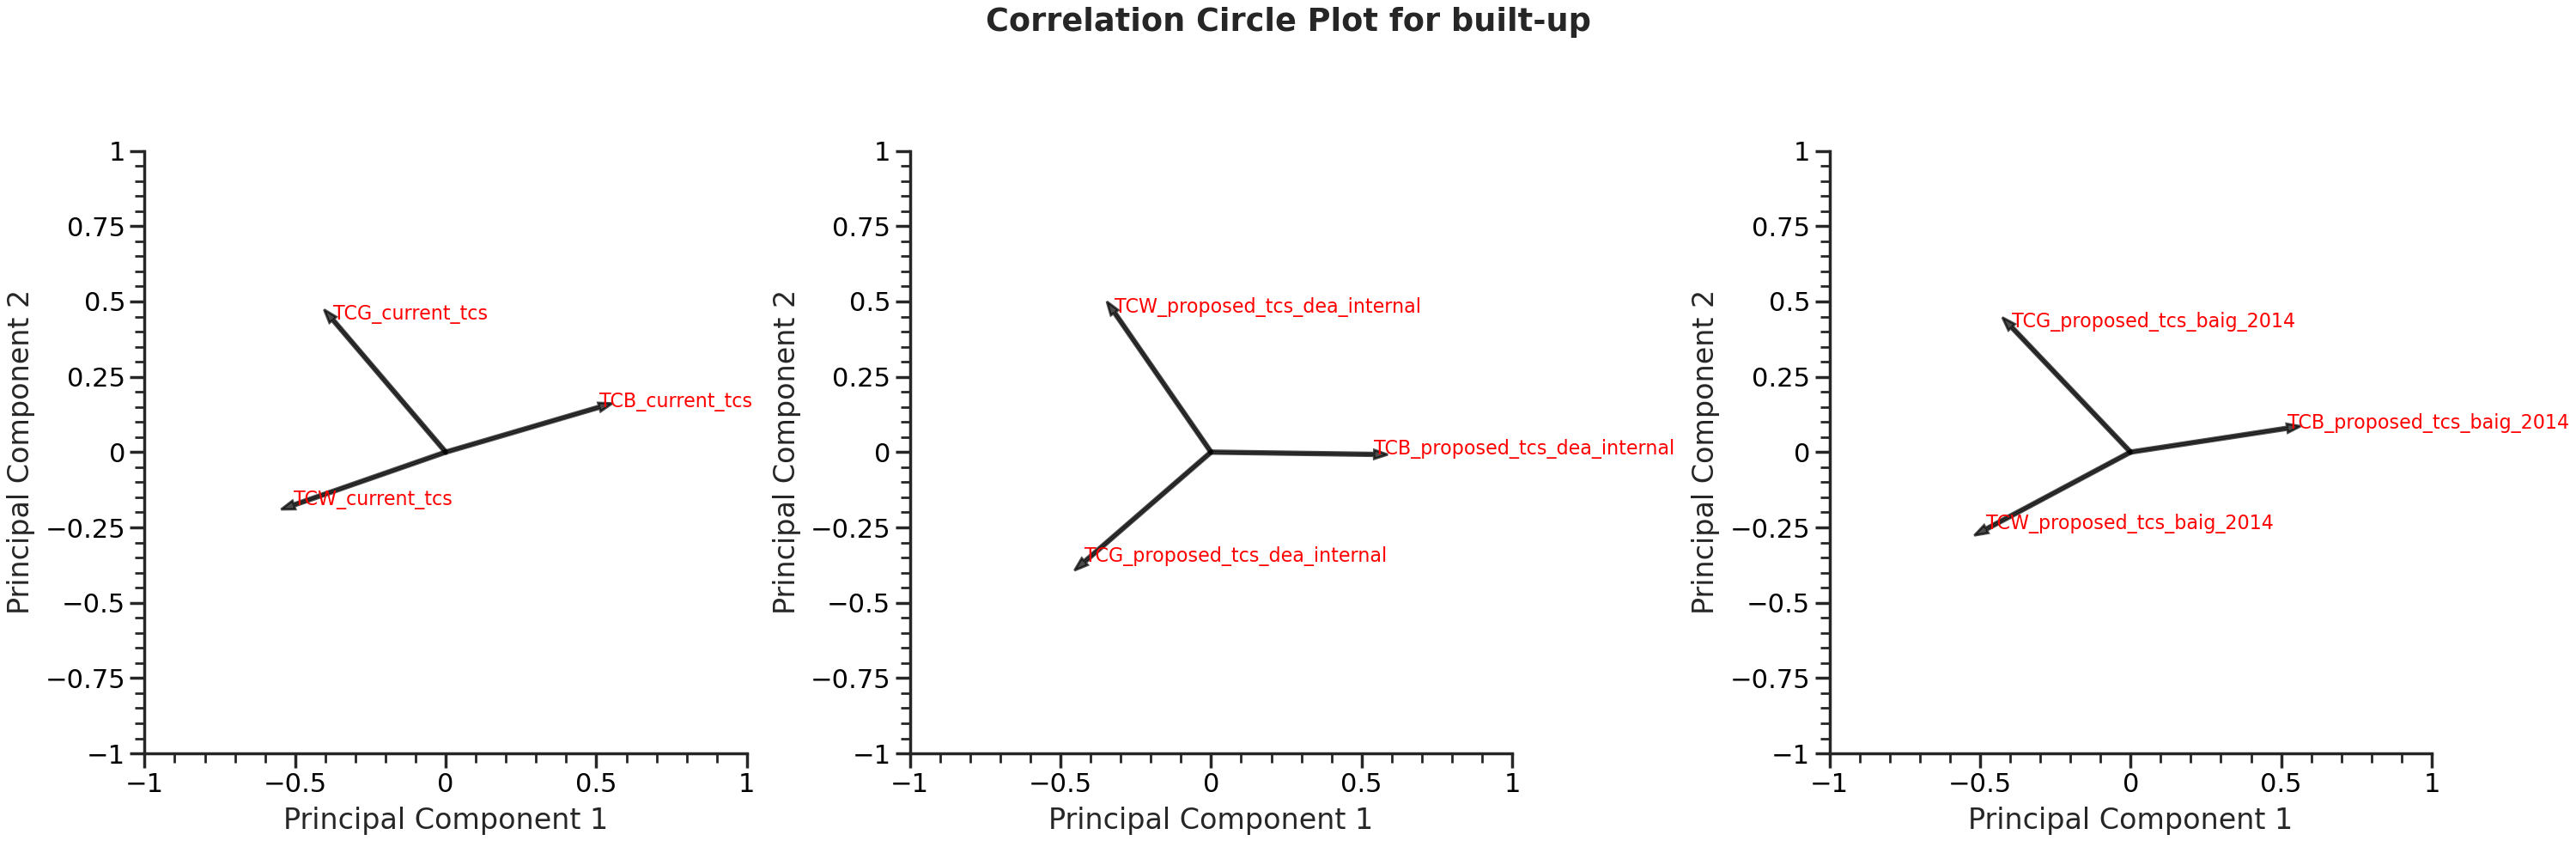

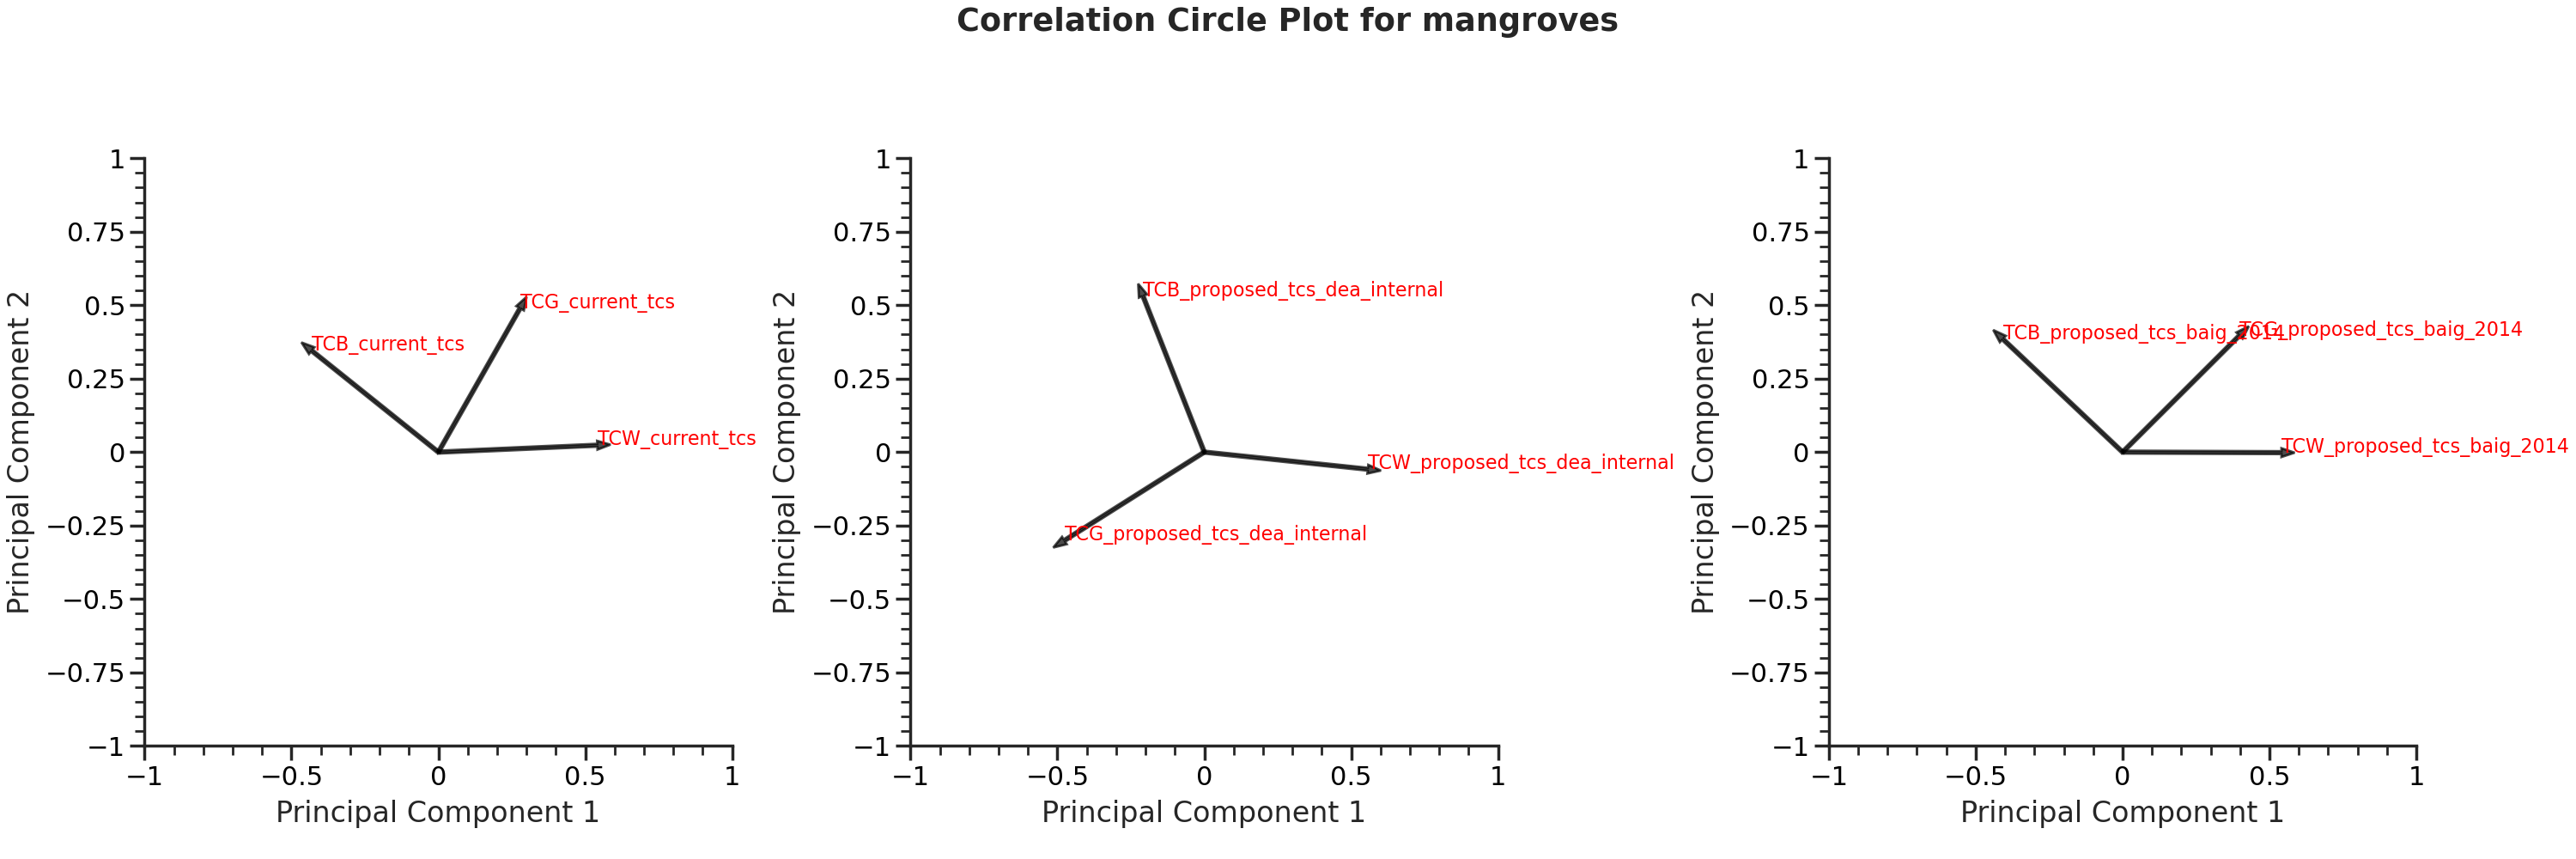

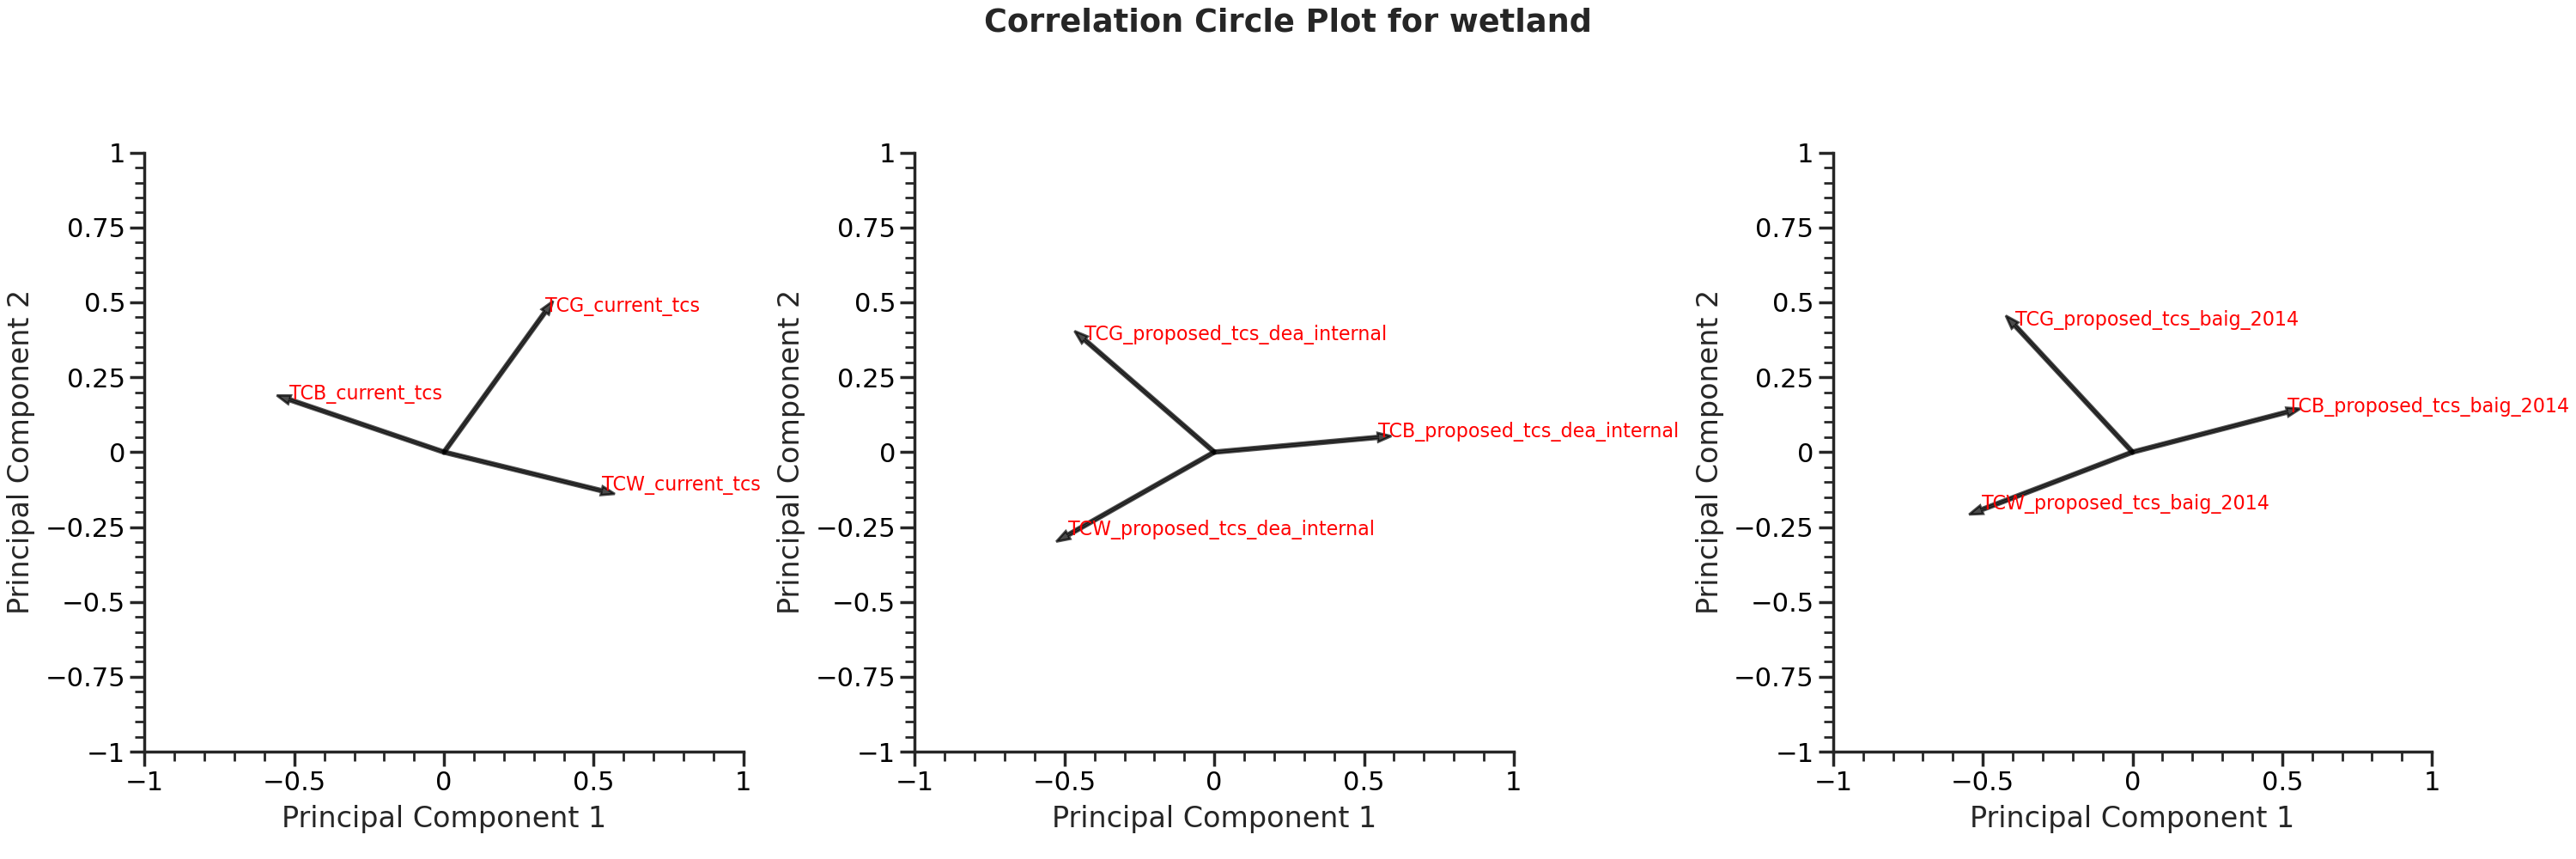

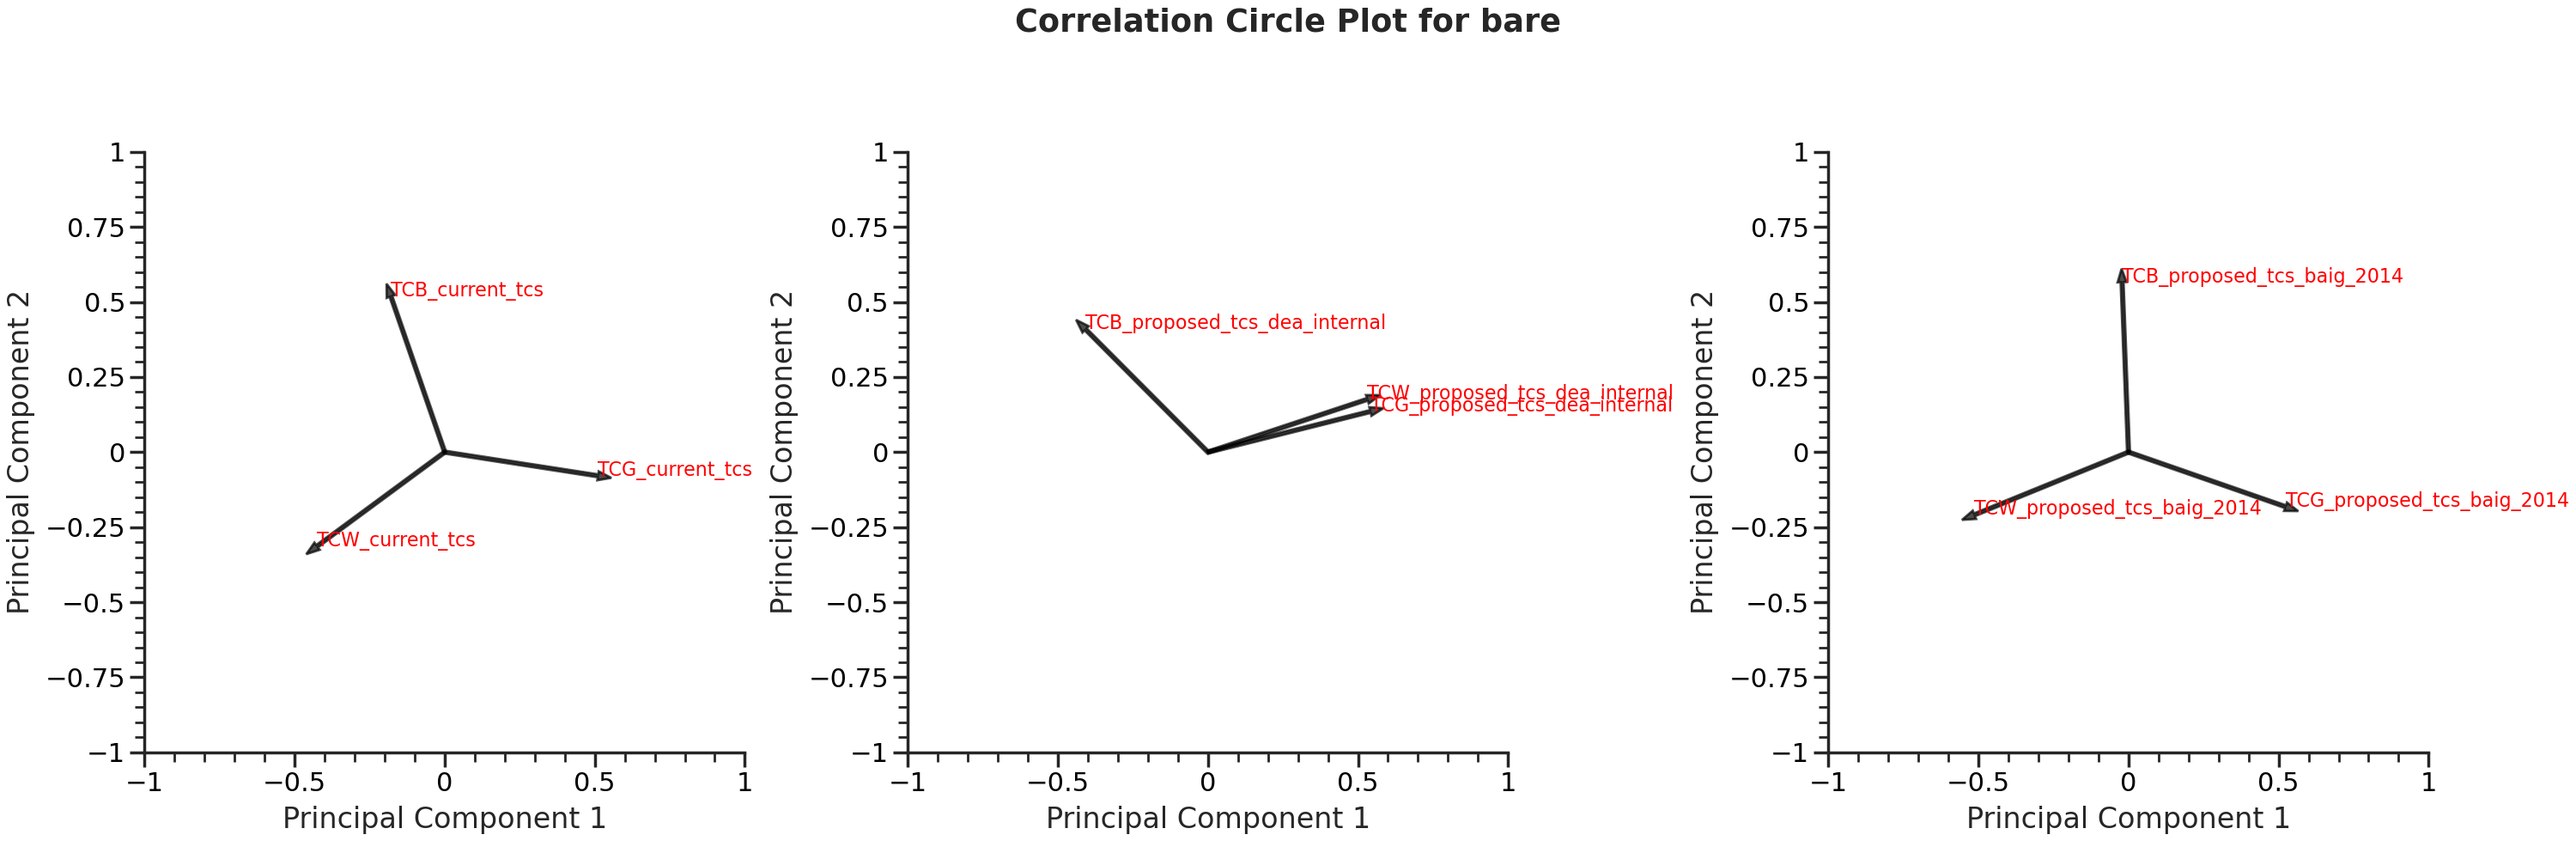

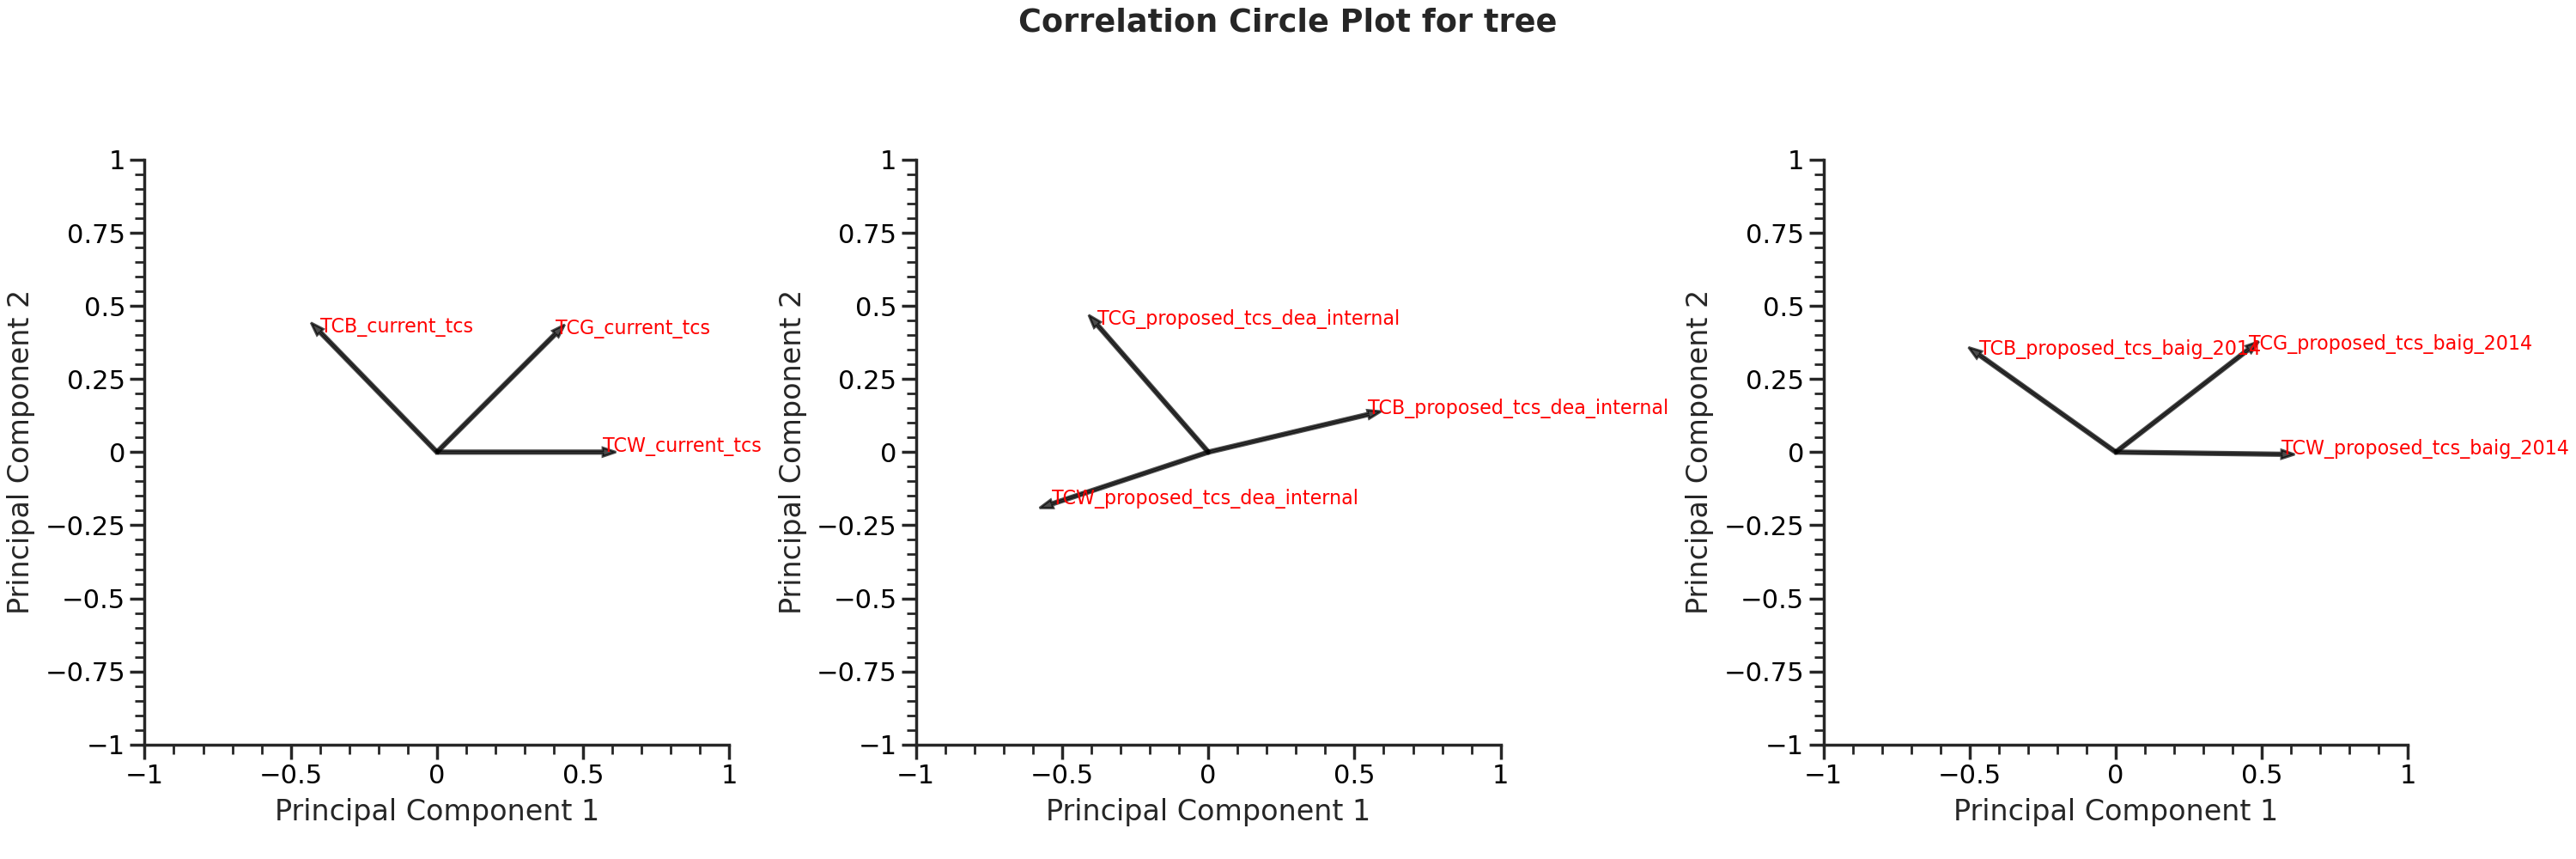

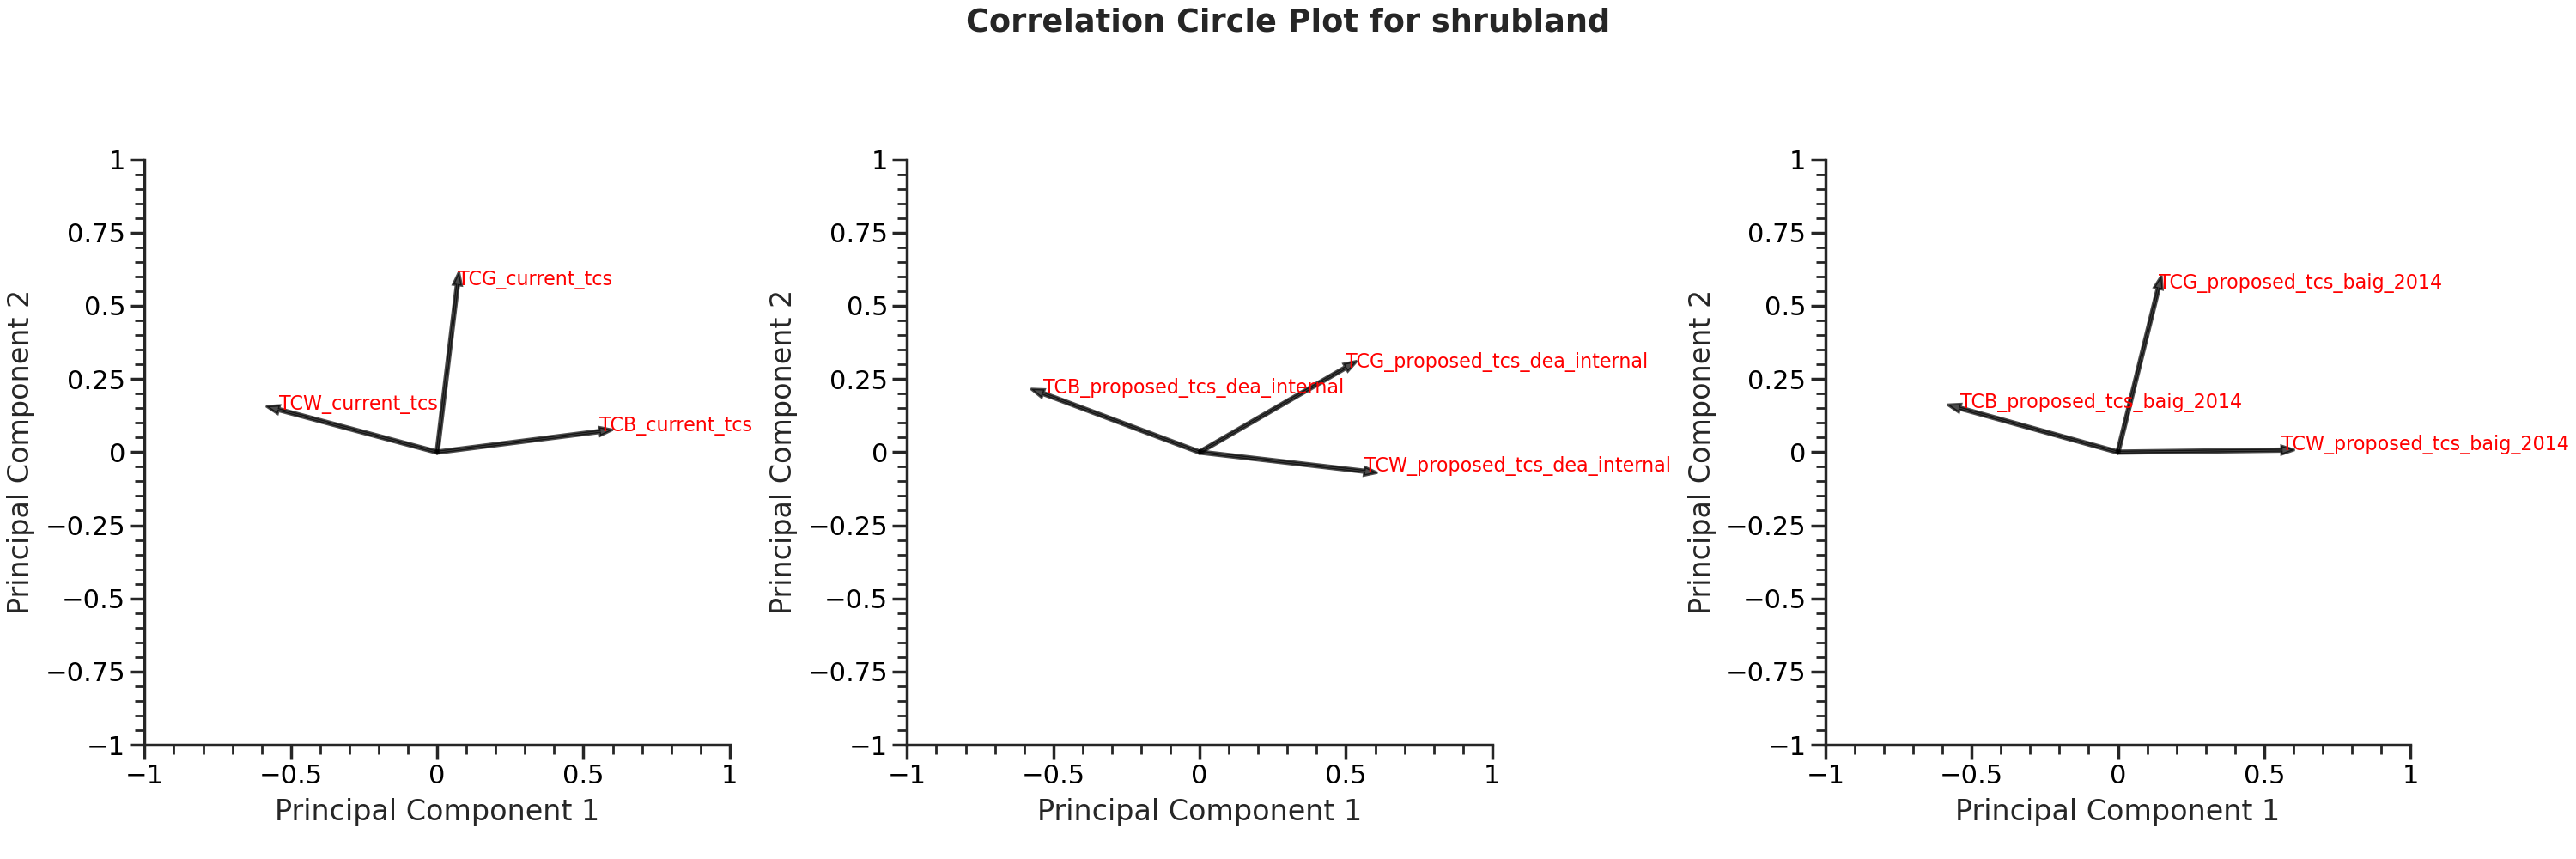

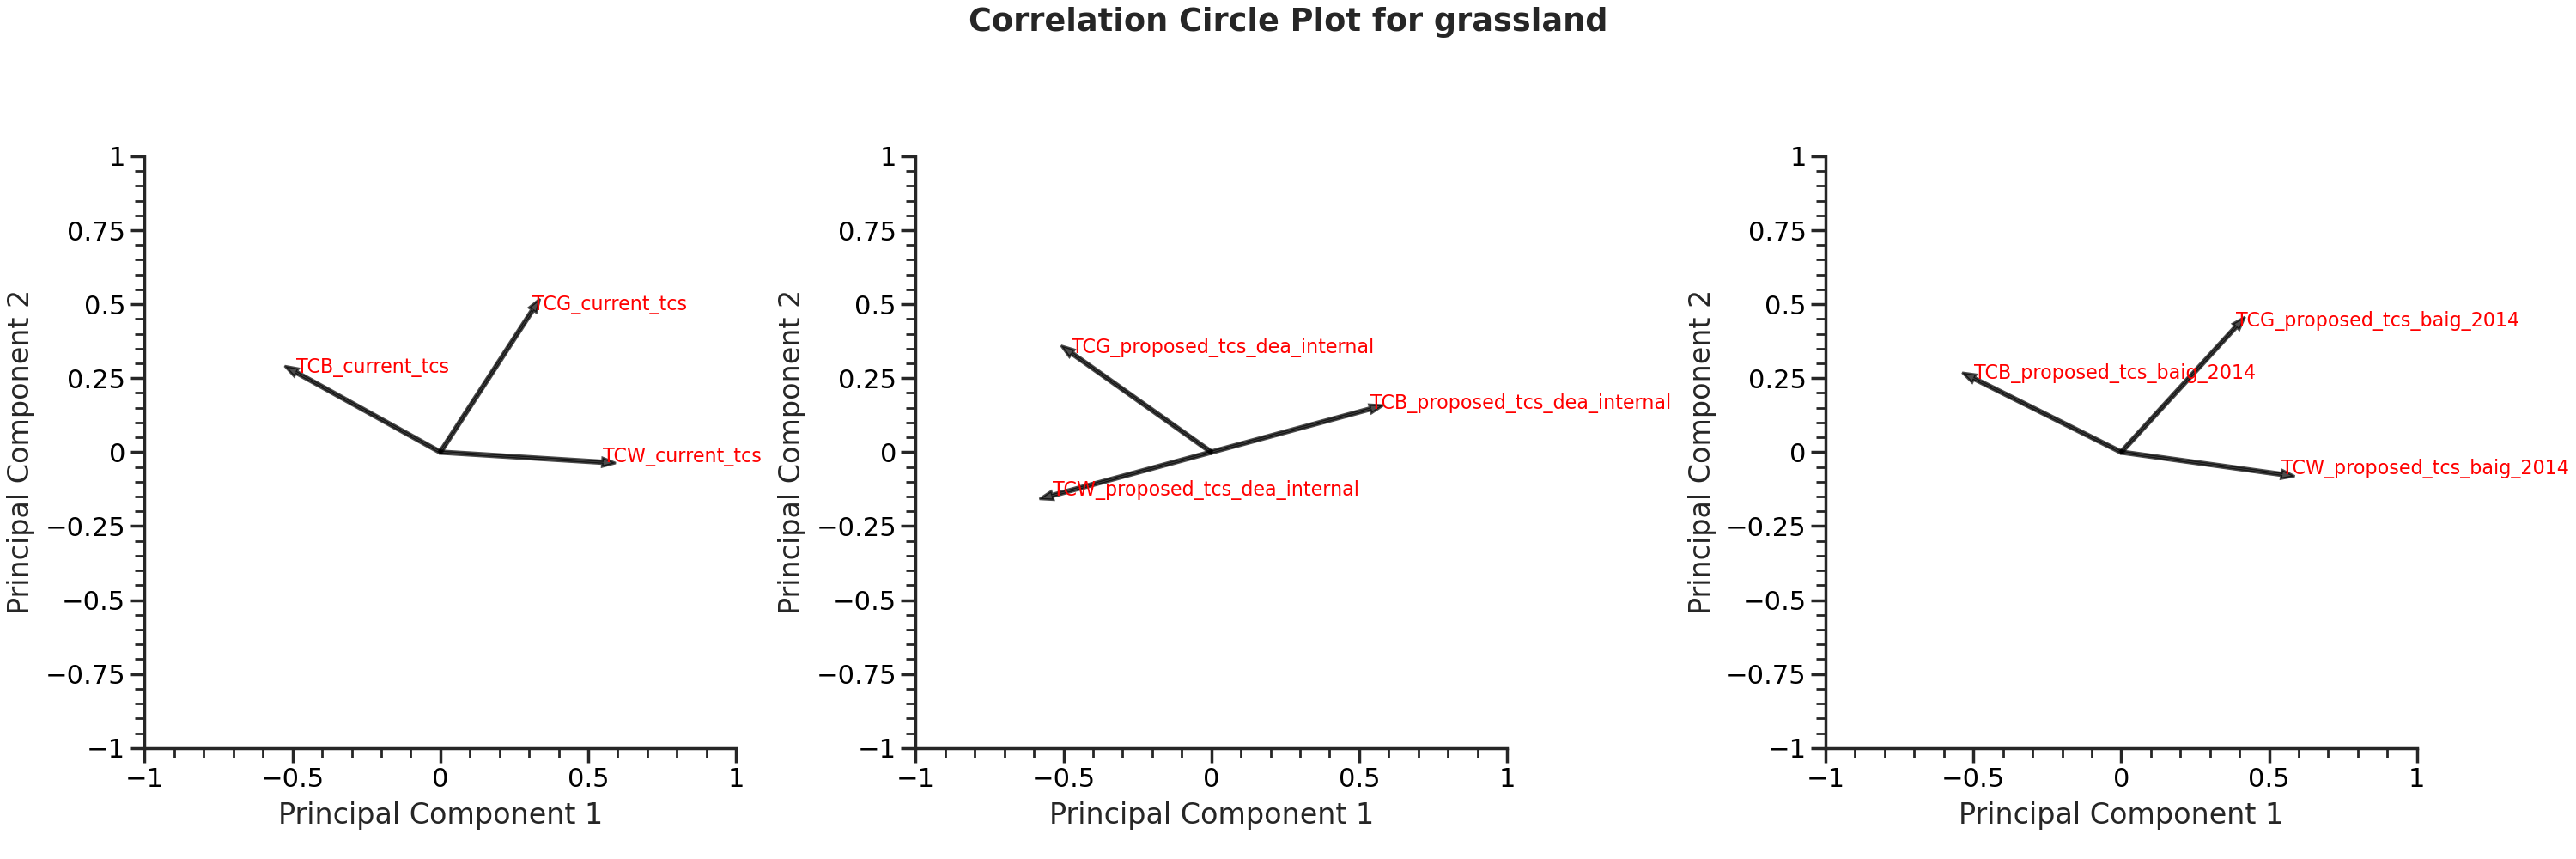

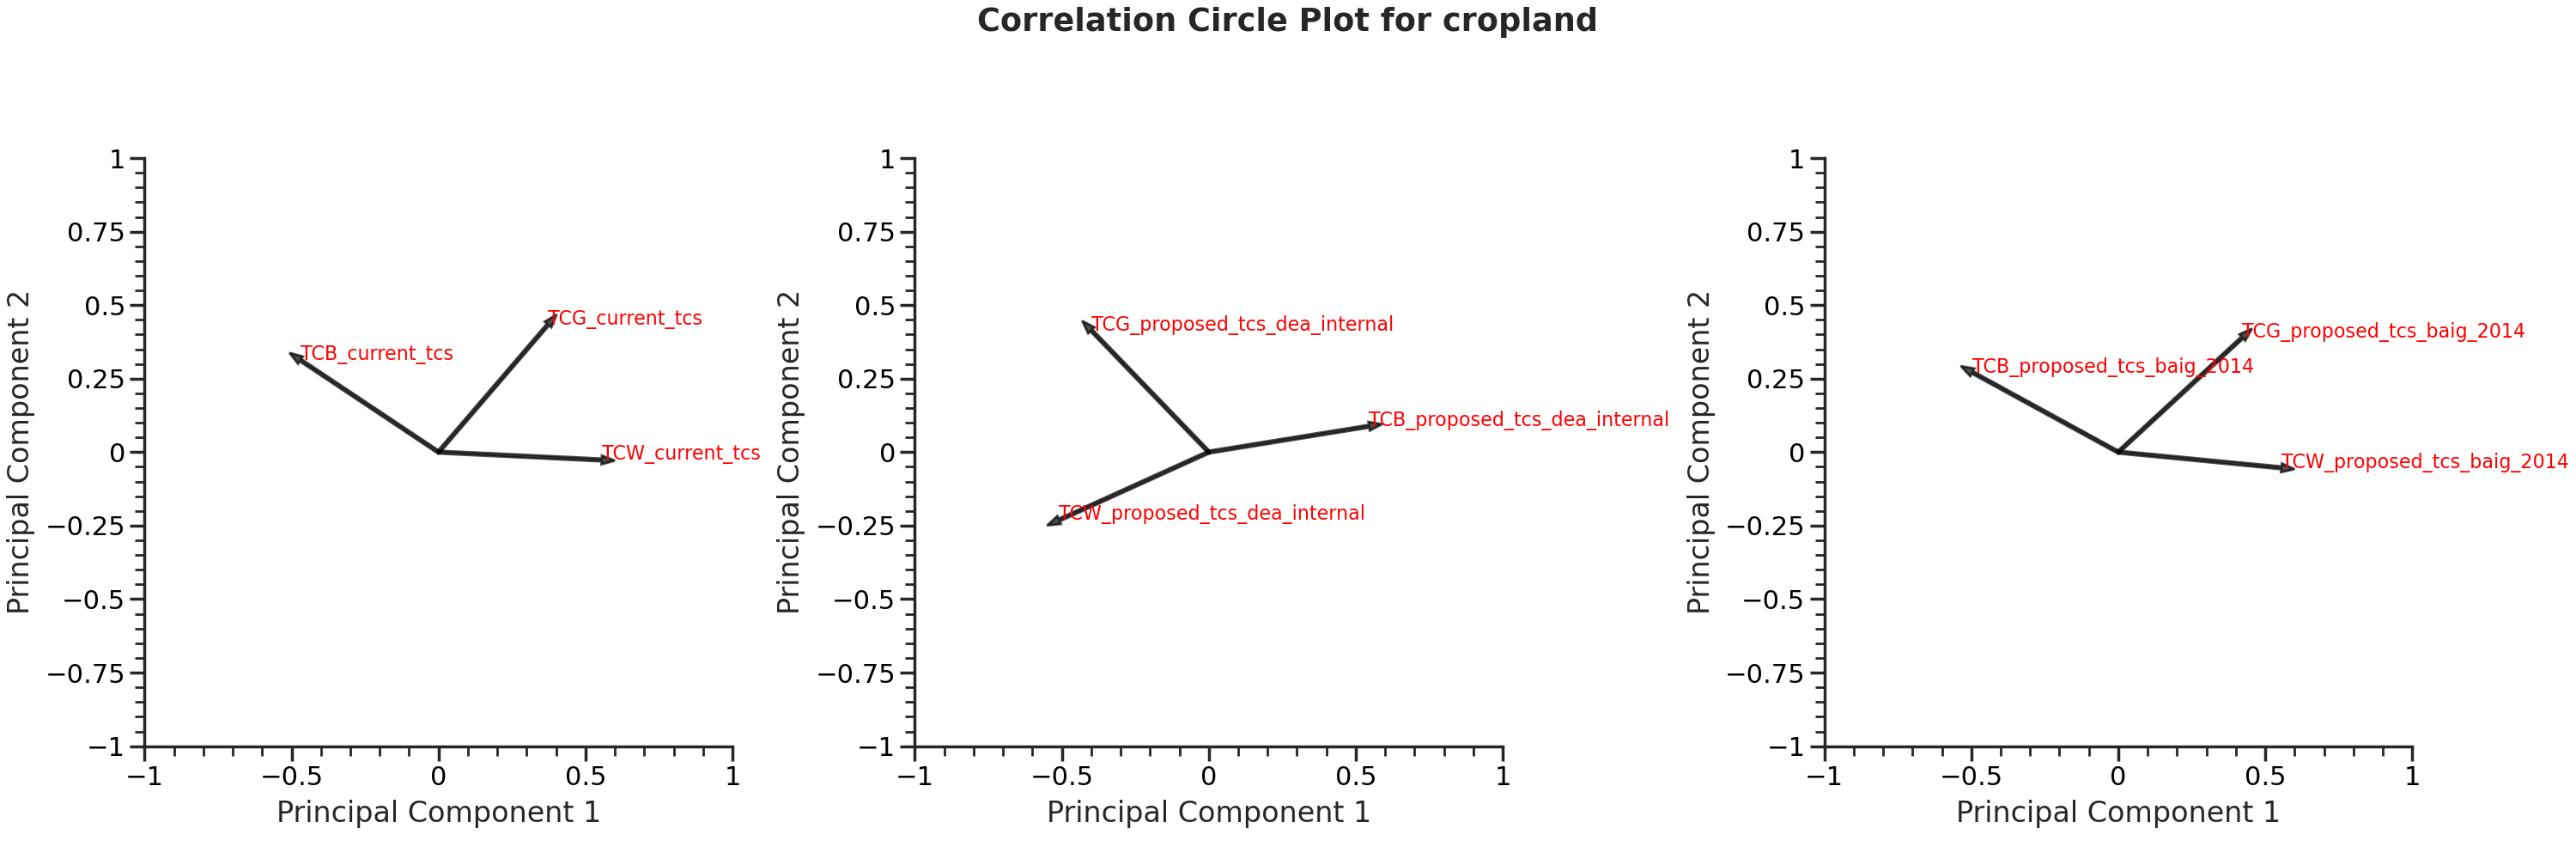

In [32]:
for i, target in enumerate(target_names):
    f, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

    for i, (tc_list_name, tc_list) in enumerate(pca_tc_lists.items()):
        ax = axs[i]

        tc_df = cdf[cdf["class_name"] == target]
        tc_df = tc_df[tc_list]

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(tc_df)

        df = pd.DataFrame(scaled_data, columns=tc_df.columns)

        pca = PCA()
        pca_results = pca.fit_transform(df)
        explained_variances = pca.explained_variance_ratio_
        loadings = pca.components_.T * np.sqrt(explained_variances)

        # Add variable labels to the plot
        for j, feature in enumerate(df.columns):

            # Add the name of the variable near the arrow
            ax.annotate(
                feature, (loadings[j, 0], loadings[j, 1]), color="red", fontsize=8
            )

            # Add an arrow representing the variable on the new axis
            ax.arrow(
                0,
                0,
                loadings[j, 0],
                loadings[j, 1],
                color="black",
                alpha=0.7,
                width=0.01,
            )
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")
        ax.set_box_aspect(1)
        ax.set_ylim(-1, 1)
        ax.set_xlim(-1, 1)

    f.suptitle(f"Correlation Circle Plot for {target}")
    f.savefig(
        f"{output_dir}/pca_correlation_circle_plot_{target}.png",
        dpi=100,
        bbox_inches="tight",
    )
    plt.close()

In [33]:
target_names = list(set(cdf["class_name"]))

fig, axs = plt.subplots((len(target_names)), 3, figsize=(12, 4 * (len(target_names))), layout="constrained")

for row_idx, target in enumerate(target_names):
    for col_idx, (tc_list_name, tc_list) in enumerate(pca_tc_lists.items()):
        ax = axs[row_idx, col_idx]

        class_df = cdf[cdf["class_name"] == target]
        tc_df = class_df[tc_list]

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(tc_df)

        df = pd.DataFrame(scaled_data, columns=tc_df.columns)

        pca = PCA()
        pca_results = pca.fit_transform(df)
        explained_variances = pca.explained_variance_ratio_
        loadings = pca.components_.T * np.sqrt(explained_variances)

        # Add variable labels to the plot
        for j, feature in enumerate(df.columns):
            feature_tc_label = feature.split('_')[0]
            feature_coeff_label = feature[4:]

            # Add the name of the variable near the arrow
            ax.annotate(
                feature_tc_label, (loadings[j, 0], loadings[j, 1]), color="red", fontsize=12
            )

            # Add an arrow representing the variable on the new axis
            ax.arrow(
                0,
                0,
                loadings[j, 0],
                loadings[j, 1],
                color="black",
                alpha=0.7,
                width=0.01,
            )
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_box_aspect(1)
        ax.set_ylim(-1, 1)
        ax.set_xlim(-1, 1)
        ax.set_title(f'{target} - {feature_coeff_label}')

fig.suptitle(f"Combined correlation Circle Plots")
fig.savefig(
    f"{output_dir}/combined_pca_correlation_circle_plots.png",
    dpi=100,
    bbox_inches="tight",
)
plt.close()

## Calculate silhouette scores

Silhouette scores range from -1 to 1:

- Close to 1: Strong separation between the two classes. Points are well-clustered and far from the other class.
- Around 0: Overlap between classes. Points lie near the decision boundary.
- Negative: Misclassification or poor separation. Points may be closer to the other class than their own.

In [93]:
def plot_silhouette_heatmap(scores_df, title_suffix=""):
    """
    Plots a lower triangle heatmap of pairwise silhouette scores using matplotlib.

    Parameters:
    - scores_df: pandas DataFrame with columns ['class1', 'class2', 'sil_score']
    - title_suffix: string to append to the figure title
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Create symmetric matrix
    heatmap_data = scores_df.pivot(index='class1', columns='class2', values='sil_score')
    heatmap_data = heatmap_data.combine_first(heatmap_data.T)
    heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

    # Convert to numpy array
    data_array = heatmap_data.values
    class_labels = heatmap_data.index.tolist()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(data_array, dtype=bool))
    masked_data = np.where(mask, np.nan, data_array)

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(masked_data, cmap='YlGn', interpolation='nearest', vmin=0, vmax=1)
    cbar = fig.colorbar(cax, ticks=[0, 0.25, 0.5, 0.75, 1])
    cbar.ax.minorticks_off()

    # Set axis labels
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_yticklabels(class_labels)

    # Hide tick marks but keep labels
    ax.tick_params(axis='x', which='both', bottom=False, top=False)
    ax.tick_params(axis='y', which='both', left=False, right=False)

    # Annotate each visible cell
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            score = masked_data[i, j]
            if not np.isnan(score):
                ax.text(j, i, f"{score:.2f}", ha='center', va='center', color='black')

    # Title with suffix
    plt.title(f'Pairwise Silhouette Scores Heatmap {title_suffix}')
    plt.savefig(f'{output_dir}/pairwise_silhouette_scores_heatmap_{title_suffix}.png', dpi=100, bbox_inches='tight')
    plt.tight_layout()


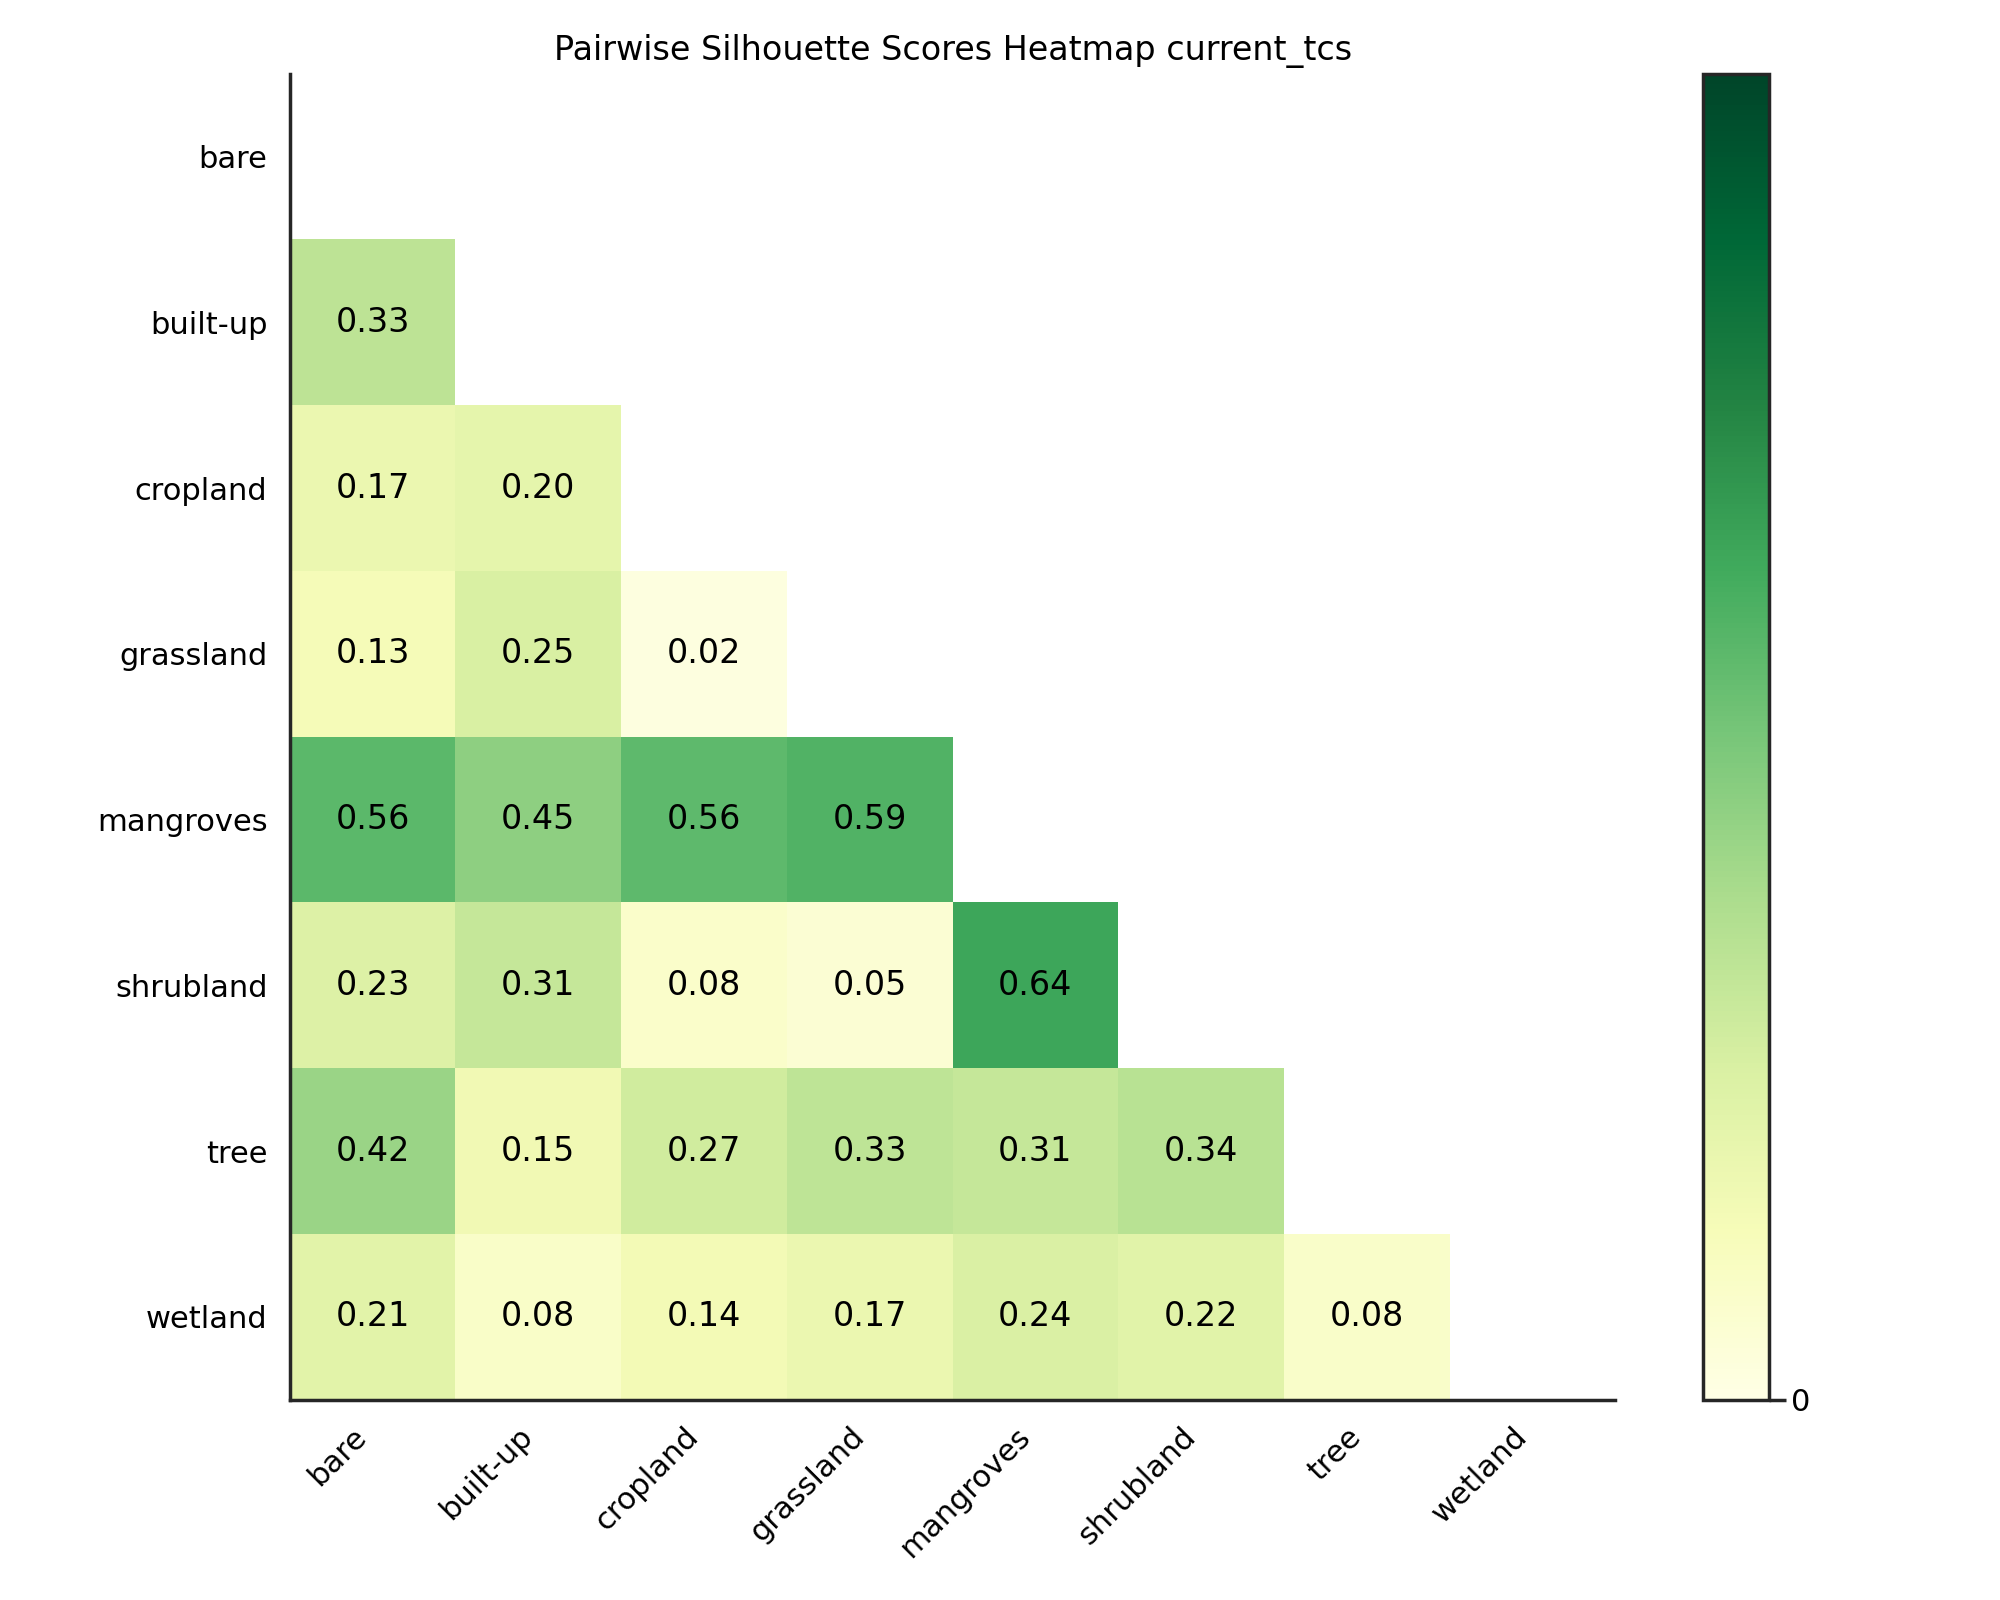

In [91]:
feature_column_names = pca_tc_lists['current_tcs']
label_column_name = 'class_name'

unique_classes = cdf[label_column].unique()

# Store pairwise silhouette scores
pairwise_scores = []

# iterate over all class pair options
for class1, class2 in combinations(unique_classes, 2):
    subset = cdf[cdf[label_column].isin([class1, class2])]

    # get features and labels
    features = subset[feature_column_names]
    labels = subset[label_column_name]

    # calculate silhouette score
    score = silhouette_score(features, labels)
    pairwise_scores.append({
        'class1': class1,
        'class2': class2,
        'sil_score': score
    })

scores_df = pd.DataFrame(pairwise_scores)
scores_df.to_csv(f'{output_dir}/pairwise_silhouette_scores_current_tcs.csv')

plot_silhouette_heatmap(scores_df, 'current_tcs')

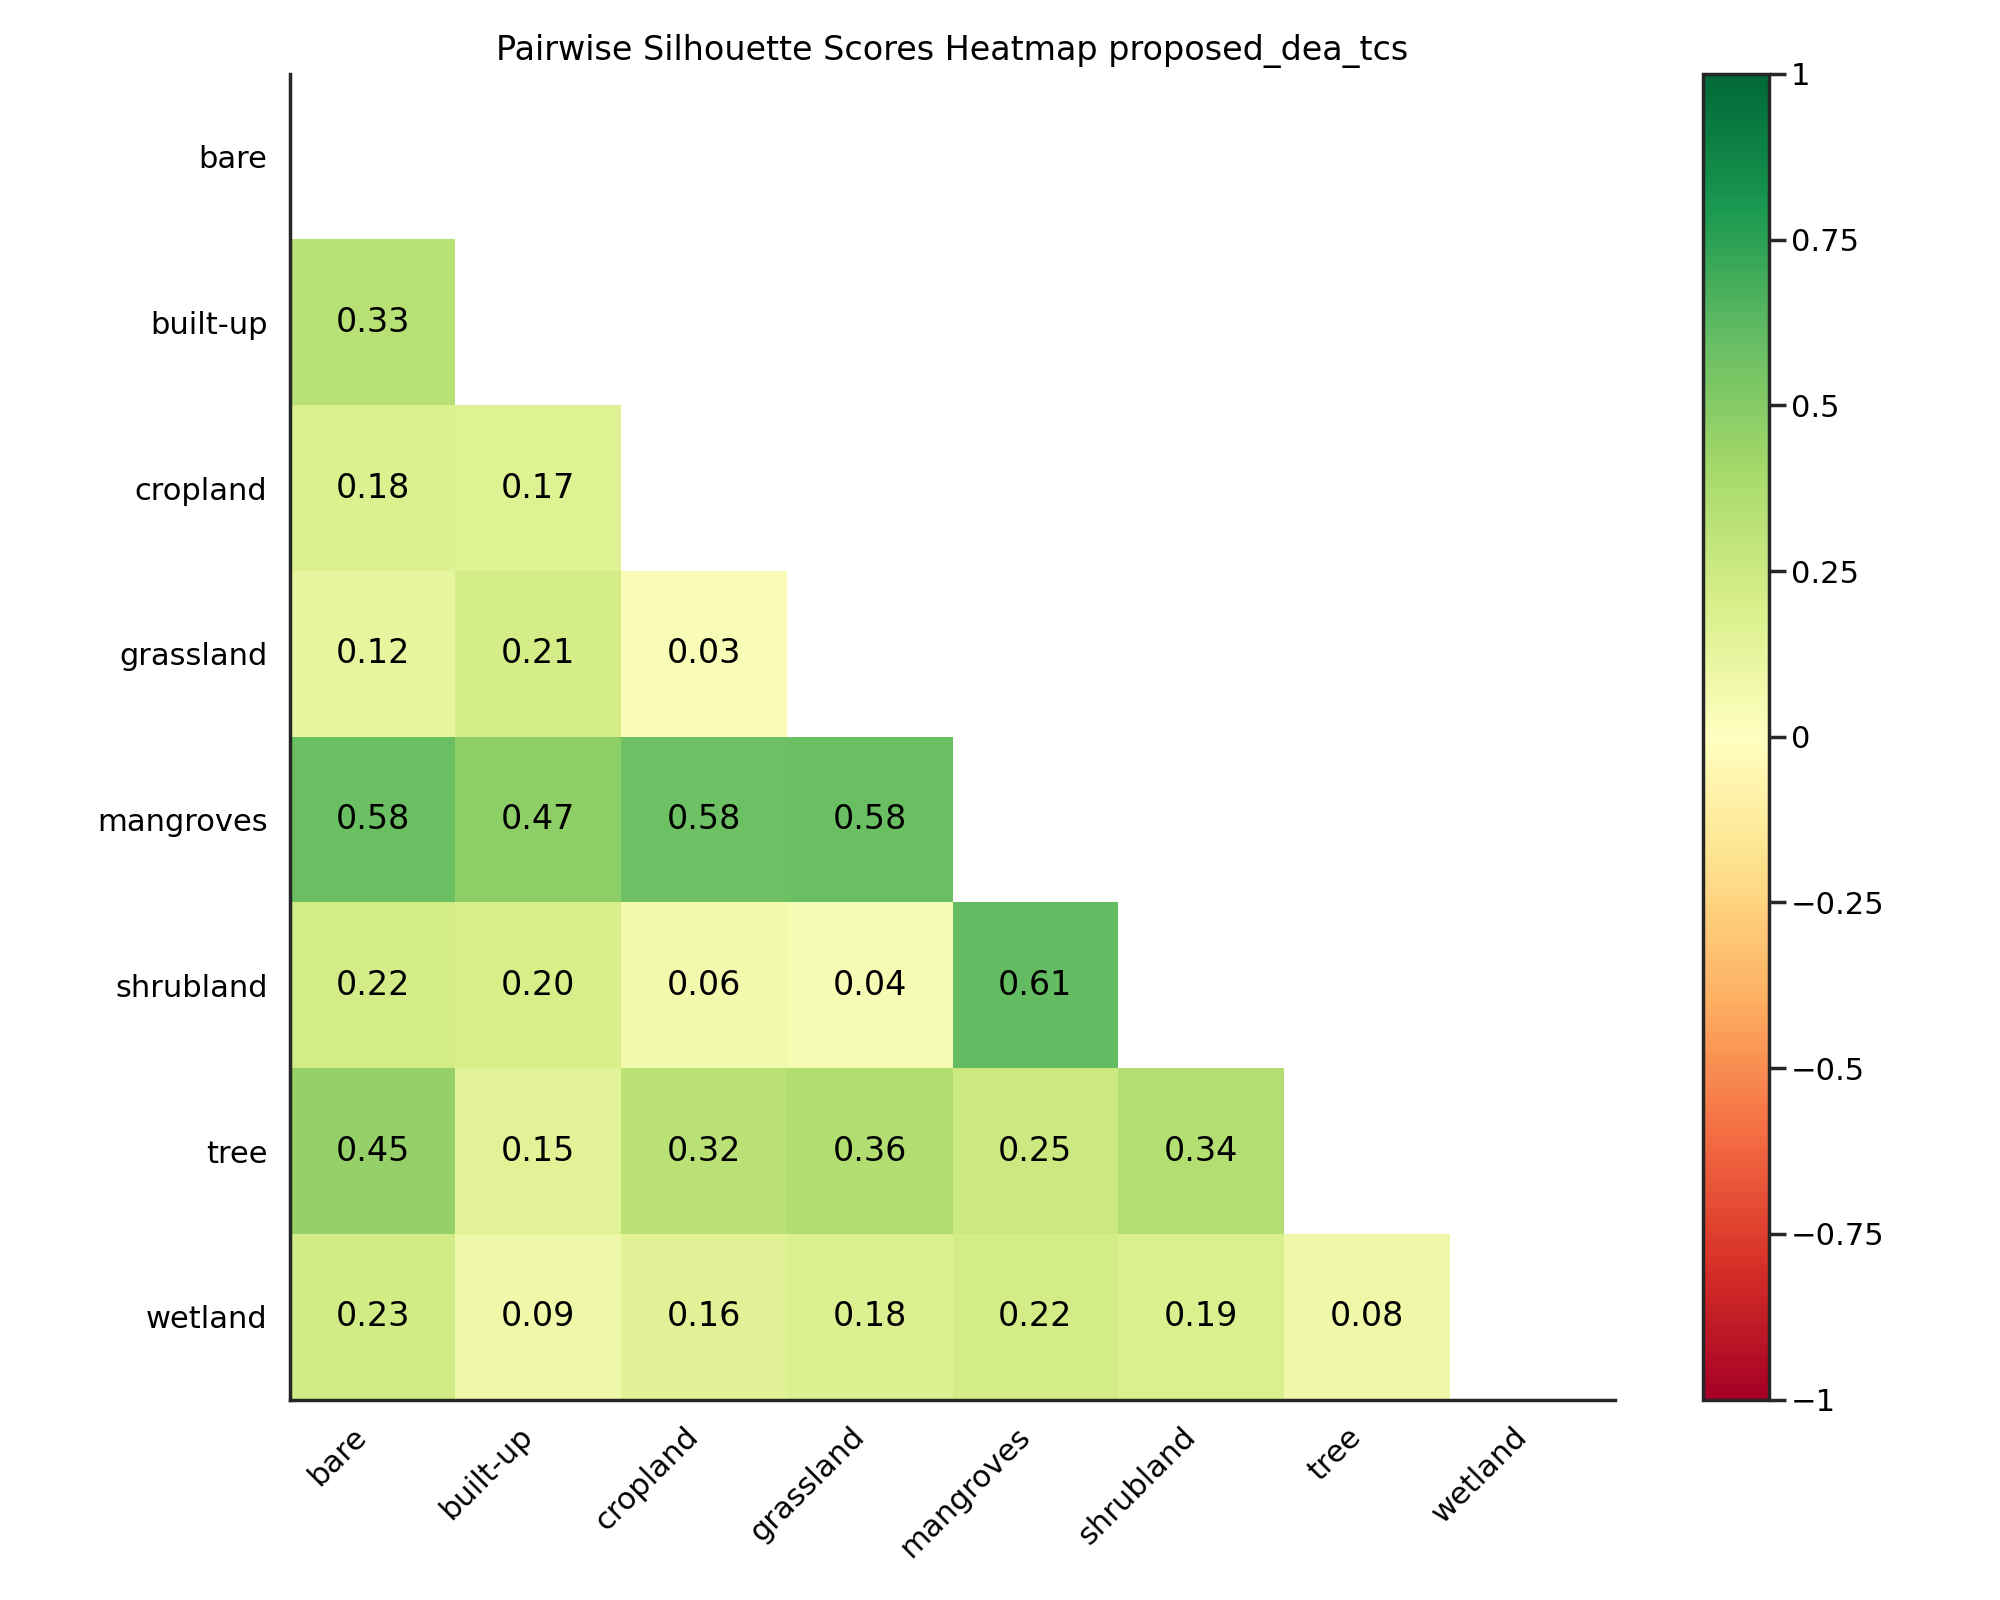

In [87]:
feature_column_names = pca_tc_lists['proposed_dea_tcs']
label_column_name = 'class_name'

unique_classes = cdf[label_column].unique()

# Store pairwise silhouette scores
pairwise_scores = []

# iterate over all class pair options
for class1, class2 in combinations(unique_classes, 2):
    subset = cdf[cdf[label_column].isin([class1, class2])]

    # get features and labels
    features = subset[feature_column_names]
    labels = subset[label_column_name]

    # calculate silhouette score
    score = silhouette_score(features, labels)
    pairwise_scores.append({
        'class1': class1,
        'class2': class2,
        'sil_score': score
    })

scores_df = pd.DataFrame(pairwise_scores)
scores_df.to_csv(f'{output_dir}/pairwise_silhouette_scores_proposed_dea_tcs.csv')

plot_silhouette_heatmap(scores_df, 'proposed_dea_tcs')

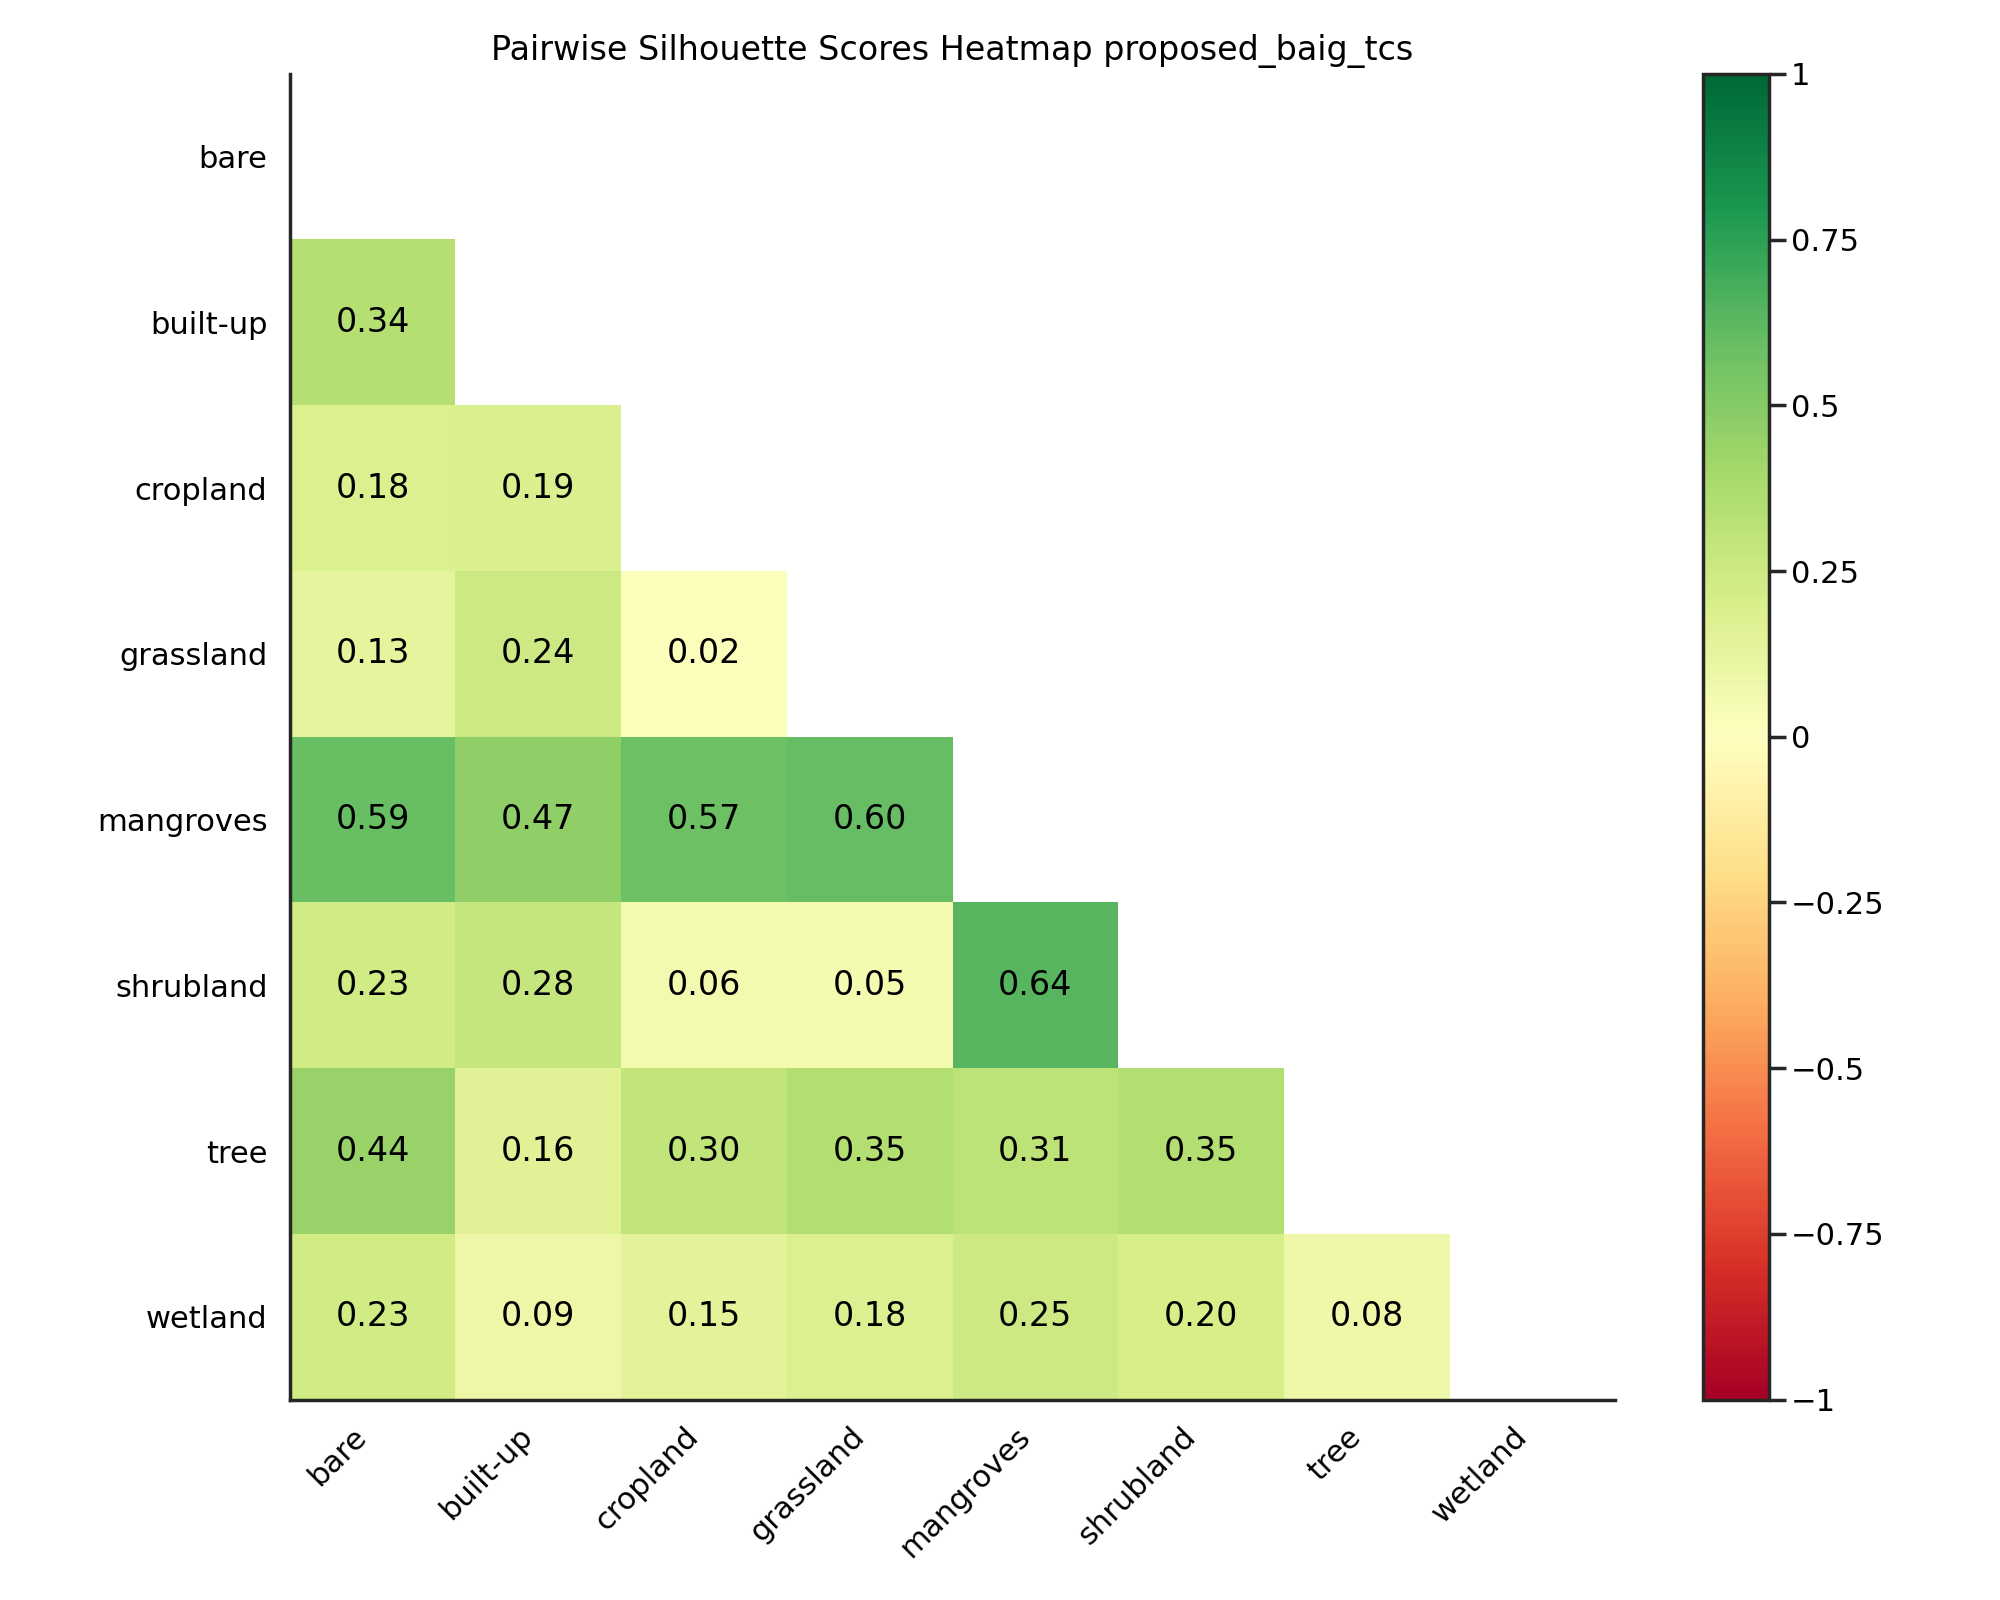

In [88]:
feature_column_names = pca_tc_lists['proposed_baig_tcs']
label_column_name = 'class_name'

unique_classes = cdf[label_column].unique()

# Store pairwise silhouette scores
pairwise_scores = []

# iterate over all class pair options
for class1, class2 in combinations(unique_classes, 2):
    subset = cdf[cdf[label_column].isin([class1, class2])]

    # get features and labels
    features = subset[feature_column_names]
    labels = subset[label_column_name]

    # calculate silhouette score
    score = silhouette_score(features, labels)
    pairwise_scores.append({
        'class1': class1,
        'class2': class2,
        'sil_score': score
    })

scores_df = pd.DataFrame(pairwise_scores)
scores_df.to_csv(f'{output_dir}/pairwise_silhouette_scores_proposed_baig_tcs.csv')

plot_silhouette_heatmap(scores_df, 'proposed_baig_tcs')